# Exploratory Data Analysis: Tourist Accommodation Anomaly Detection

The purpose of this notebook is to explore, clean, engineer and prepare the scraped accommodation
dataset so that it is ready for unsupervised anomaly detection with **Isolation Forest** and
**Local Outlier Factor (LOF)**.

**Notebook structure**

1. Data loading & overview
2. Data quality audit (types, missing values, duplicates, consistency)
3. Univariate analysis
4. Geographic analysis
5. Bivariate / multivariate analysis (correlations, price drivers)
6. Data cleaning
7. Feature engineering
8. Variable treatment & transformations
9. Preliminary anomaly detection (business rules)
10. Dimensionality reduction preview (PCA)
11. Risks and limitations of the dataset
12. Final dataset preparation for Isolation Forest / LOF

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("default")

print("Libraries loaded")

Libraries loaded


In [2]:
# Load raw data
df_raw = pd.read_csv(
    "data/Booking2026-07-03_3m.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

print("=" * 60)
print("DIMENSIONS")
print("=" * 60)
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")

print("\nFirst rows:")
display(df_raw.head())

DIMENSIONS
Rows: 109,352
Columns: 25

First rows:


,id,nombre,idHabitacion,nombreHabitacion,idLocalizacion,nombreCCAA,nombreProvincia,nombreMunicipio,nombreLocalizacion,tipo,numHabitaciones,numBanos,metros,piscina_flag,playa_flag,estrellas,precio,oferta,precioSinOferta,capacidad,desayuno,cancelacion,fechaActual,fechaEntrada,fechaSalida
0,10000125,Apartamentos Villa Zoila Nigrán,1000012502,Apartamento de 1 dormitorio,-394030.0,Galicia,Pontevedra,Nigrán,Nigrán,Apartamento,1.0,1.0,55,0,1,,1117.24,99.56,1216.8,2.0,,0.0,2026-07-03,2026-10-03,2026-10-10
1,10000734,Hostal Carlos III,1000073405,Habitación Deluxe - 1 cama grande,-398093.0,Andalucía,Córdoba,"Victoria, La",Aldea Quintana,Hostal o pensión,0.0,0.0,,0,0,,420.00,0.00,0.0,2.0,,1.0,2026-07-03,2026-10-03,2026-10-10
2,10001085,Vive tu vida soñada delante del mar,1000108501,Apartamento de 2 dormitorios,-386902.0,Cataluña,Gerona,"Escala, L'",L'Escala,Apartamento,2.0,1.0,175,0,1,,1080.02,0.00,0.0,2.0,,0.0,2026-07-03,2026-10-03,2026-10-10
3,1000112,La Vista de Medina By La Vista Medina Stays,100011202,Estudio,-391732.0,Andalucía,Cádiz,Medina-Sidonia,Medina Sidonia,Apartamento,1.0,1.0,25,1,0,2,630.00,0.00,0.0,2.0,,1.0,2026-07-03,2026-10-03,2026-10-10
4,1000115,Hostal Catalina de Austria,100011502,Habitación Doble - 2 camas,-404562.0,Castilla y León,Palencia,Torquemada,Torquemada,Hostal o pensión,0.0,0.0,,0,0,2,418.00,0.00,0.0,2.0,,1.0,2026-07-03,2026-10-03,2026-10-10


In [3]:
# Translate column names to English for a fully English notebook.

column_mapping = {
    "id": "id",
    "nombre": "name",
    "idHabitacion": "room_id",
    "nombreHabitacion": "room_name",
    "idLocalizacion": "location_id",
    "nombreCCAA": "region",
    "nombreProvincia": "province",
    "nombreMunicipio": "municipality",
    "nombreLocalizacion": "locality",
    "tipo": "property_type",
    "numHabitaciones": "num_rooms",
    "numBanos": "num_bathrooms",
    "metros": "sqm",
    "piscina_flag": "pool_flag",
    "playa_flag": "beach_flag",
    "estrellas": "stars",
    "precio": "price",
    "oferta": "discount_amount",
    "precioSinOferta": "price_without_discount",
    "capacidad": "capacity",
    "desayuno": "breakfast",
    "cancelacion": "cancellation",
    "fechaActual": "current_date",
    "fechaEntrada": "checkin_date",
    "fechaSalida": "checkout_date",
}

df = df_raw.rename(columns=column_mapping)
df.columns.tolist()

['id',
 'name',
 'room_id',
 'room_name',
 'location_id',
 'region',
 'province',
 'municipality',
 'locality',
 'property_type',
 'num_rooms',
 'num_bathrooms',
 'sqm',
 'pool_flag',
 'beach_flag',
 'stars',
 'price',
 'discount_amount',
 'price_without_discount',
 'capacity',
 'breakfast',
 'cancellation',
 'current_date',
 'checkin_date',
 'checkout_date']

In [4]:
print("=" * 60)
print("GENERAL INFO")
print("=" * 60)

df.info()

variable_summary = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str),
    "non_null": df.notnull().sum(),
    "nulls": df.isnull().sum()
})

display(variable_summary)

GENERAL INFO
<class 'pandas.DataFrame'>
RangeIndex: 109352 entries, 0 to 109351
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      109352 non-null  int64  
 1   name                    109333 non-null  str    
 2   room_id                 109352 non-null  int64  
 3   room_name               109352 non-null  str    
 4   location_id             109298 non-null  float64
 5   region                  109235 non-null  str    
 6   province                109235 non-null  str    
 7   municipality            109235 non-null  str    
 8   locality                109235 non-null  str    
 9   property_type           109279 non-null  str    
 10  num_rooms               109298 non-null  float64
 11  num_bathrooms           109298 non-null  float64
 12  sqm                     109298 non-null  str    
 13  pool_flag               109352 non-null  int64  
 14  beach_flag        

,variable,dtype,non_null,nulls
id,id,int64,109352,0
name,name,str,109333,19
room_id,room_id,int64,109352,0
room_name,room_name,str,109352,0
location_id,location_id,float64,109298,54
region,region,str,109235,117
province,province,str,109235,117
municipality,municipality,str,109235,117
locality,locality,str,109235,117
property_type,property_type,str,109279,73


In [5]:
numeric_vars = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_vars = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("=" * 60)
print("VARIABLE TYPES")
print("=" * 60)
print(f"Numeric variables ({len(numeric_vars)}): {numeric_vars}")
print(f"Categorical variables ({len(categorical_vars)}): {categorical_vars}")

cardinality = pd.DataFrame({
    "variable": df.columns,
    "unique_values": [df[c].nunique() for c in df.columns]
}).sort_values("unique_values")

display(cardinality)

VARIABLE TYPES
Numeric variables (12): ['id', 'room_id', 'location_id', 'num_rooms', 'num_bathrooms', 'pool_flag', 'beach_flag', 'price', 'discount_amount', 'price_without_discount', 'capacity', 'cancellation']
Categorical variables (13): ['name', 'room_name', 'region', 'province', 'municipality', 'locality', 'property_type', 'sqm', 'stars', 'breakfast', 'current_date', 'checkin_date', 'checkout_date']


,variable,unique_values
24,checkout_date,1
22,current_date,1
23,checkin_date,1
19,capacity,1
13,pool_flag,2
14,beach_flag,2
21,cancellation,2
20,breakfast,2
15,stars,6
11,num_bathrooms,18


In [6]:
print("=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)

print(f"Records: {len(df):,}")
print(f"Variables: {len(df.columns)}")
print(f"Numeric variables: {len(numeric_vars)}")
print(f"Categorical variables: {len(categorical_vars)}")
print(f"Exact duplicates: {df.duplicated().sum()}")

display(df[numeric_vars].describe())

EXECUTIVE SUMMARY
Records: 109,352
Variables: 25
Numeric variables: 12
Categorical variables: 13
Exact duplicates: 716


,id,room_id,location_id,num_rooms,num_bathrooms,pool_flag,beach_flag,price,discount_amount,price_without_discount,capacity,cancellation
count,1.093520e+05,1.093520e+05,1.092980e+05,109298.000000,109298.000000,109352.000000,109352.000000,109298.000000,109298.000000,109298.000000,109298.0,109298.000000
mean,9.673352e+06,9.667988e+08,1.275863e+08,1.849887,1.385140,0.357689,0.130615,1338.947992,45.012128,370.621552,2.0,0.591511
std,4.981160e+06,4.986468e+08,3.144134e+08,1.360371,1.021998,0.479322,0.336980,1955.817830,200.691568,1109.584676,0.0,0.491557
min,1.179200e+04,0.000000e+00,-1.439182e+06,0.000000,0.000000,0.000000,0.000000,59.500200,0.000000,0.000000,2.0,0.000000
25%,6.253760e+06,6.244997e+08,-3.977100e+05,1.000000,1.000000,0.000000,0.000000,694.000000,0.000000,0.000000,2.0,0.000000
50%,1.051575e+07,1.051107e+09,-3.860590e+05,2.000000,1.000000,0.000000,0.000000,961.395000,0.000000,0.000000,2.0,1.000000
75%,1.384955e+07,1.384923e+09,-3.731440e+05,3.000000,2.000000,1.000000,0.000000,1455.430000,0.000000,0.000000,2.0,1.000000
max,1.679613e+07,1.679613e+09,9.000642e+08,40.000000,20.000000,1.000000,1.000000,169490.000000,21954.240000,109771.200000,2.0,1.000000


### Initial conclusions

- The dataset contains 109,352 records and 25 variables.
- There are 716 exact duplicate rows.
- `sqm` and `stars` are stored as text/mixed types and need numeric conversion.
- `capacity`, `current_date`, `checkin_date` and `checkout_date` have cardinality 1 (constant across the whole dataset), they are not useful for our analysis.
- Identifier variables (`id`, `room_id`, `location_id`, `name`, `room_name`) have very
  high or maximal cardinality and are not usable as model features, we will only use them as traceability keys.

## 2. Data Quality Audit

In [7]:
# Working copy + numeric conversion
df_eda = df.copy()

df_eda["sqm"] = pd.to_numeric(df_eda["sqm"], errors="coerce")
df_eda["stars"] = pd.to_numeric(df_eda["stars"], errors="coerce")

print(df_eda.dtypes)

id                          int64
name                          str
room_id                     int64
room_name                     str
location_id               float64
region                        str
province                      str
municipality                  str
locality                      str
property_type                 str
num_rooms                 float64
num_bathrooms             float64
sqm                       float64
pool_flag                   int64
beach_flag                  int64
stars                     float64
price                     float64
discount_amount           float64
price_without_discount    float64
capacity                  float64
breakfast                     str
cancellation              float64
current_date                  str
checkin_date                  str
checkout_date                 str
dtype: object


In [8]:
nulls = pd.DataFrame({
    "variable": df_eda.columns,
    "nulls": df_eda.isnull().sum(),
    "pct": round(df_eda.isnull().mean() * 100, 2)
}).sort_values("pct", ascending=False)

display(nulls)
display(nulls[nulls["nulls"] > 0])

,variable,nulls,pct
stars,stars,99693,91.17
sqm,sqm,16903,15.46
municipality,municipality,117,0.11
province,province,117,0.11
locality,locality,117,0.11
region,region,117,0.11
property_type,property_type,73,0.07
num_rooms,num_rooms,54,0.05
location_id,location_id,54,0.05
cancellation,cancellation,54,0.05


,variable,nulls,pct
stars,stars,99693,91.17
sqm,sqm,16903,15.46
municipality,municipality,117,0.11
province,province,117,0.11
locality,locality,117,0.11
region,region,117,0.11
property_type,property_type,73,0.07
num_rooms,num_rooms,54,0.05
location_id,location_id,54,0.05
cancellation,cancellation,54,0.05


In [9]:
for var in ["stars", "sqm"]:
    print("\n" + "=" * 60)
    print(f"NULLS IN {var.upper()} BY PROPERTY TYPE")
    print("=" * 60)
    table = pd.crosstab(df_eda["property_type"], df_eda[var].isna(), normalize="index") * 100
    display(table.round(2))


NULLS IN STARS BY PROPERTY TYPE


stars,False,True
property_type,,
Agroturismo,14.55,85.45
Albergue,6.10,93.90
Apartahotel,30.74,69.26
Apartamento,1.64,98.36
Barco,0.00,100.00
Bed and breakfast,4.88,95.12
Camping,9.40,90.60
Camping resort,12.50,87.50
Casa o chalet,3.94,96.06



NULLS IN SQM BY PROPERTY TYPE


sqm,False,True
property_type,,
Agroturismo,50.91,49.09
Albergue,2.07,97.93
Apartahotel,81.51,18.49
Apartamento,95.69,4.31
Barco,68.18,31.82
Bed and breakfast,8.14,91.86
Camping,54.55,45.45
Camping resort,81.94,18.06
Casa o chalet,95.77,4.23


In [10]:
duplicates = df_eda.duplicated()
print("=" * 60)
print("DUPLICATES")
print("=" * 60)
print(f"Exact duplicate rows: {duplicates.sum()}")
print(f"Percentage of total: {duplicates.sum() / len(df_eda) * 100:.2f}%")

DUPLICATES
Exact duplicate rows: 716
Percentage of total: 0.65%


In [11]:
cardinality = pd.DataFrame({
    "variable": df_eda.columns,
    "unique_values": [df_eda[c].nunique() for c in df_eda.columns]
}).sort_values("unique_values")

display(cardinality)

,variable,unique_values
24,checkout_date,1
22,current_date,1
23,checkin_date,1
19,capacity,1
13,pool_flag,2
14,beach_flag,2
21,cancellation,2
20,breakfast,2
15,stars,5
11,num_bathrooms,18


In [12]:
print("=" * 60)
print("CONSISTENCY CHECKS")
print("=" * 60)

print("Rooms = 0:", (df_eda["num_rooms"] == 0).sum())
print("Bathrooms = 0:", (df_eda["num_bathrooms"] == 0).sum())
print("Sqm <= 0:", (df_eda["sqm"] <= 0).sum())
print("Sqm < 10:", (df_eda["sqm"] < 10).sum())
print("Price <= 0:", (df_eda["price"] <= 0).sum())
print("Negative discount:", (df_eda["discount_amount"] < 0).sum())

CONSISTENCY CHECKS
Rooms = 0: 17060
Bathrooms = 0: 13788
Sqm <= 0: 0
Sqm < 10: 259
Price <= 0: 0
Negative discount: 0


In [13]:
print("=" * 60)
print("HIGHEST PRICES")
print("=" * 60)
display(
    df_eda[["name", "property_type", "province", "sqm", "price"]]
    .sort_values("price", ascending=False).head(20)
)

print("=" * 60)
print("SMALLEST SQM")
print("=" * 60)
display(
    df_eda[["name", "property_type", "sqm", "price"]]
    .sort_values("sqm", ascending=True).head(20)
)

HIGHEST PRICES


,name,property_type,province,sqm,price
10924,Triana Cool Studio,Apartamento,Gran Canaria,45.0,169490.0000
41831,"6 Bedroom Villa Oasis in Ibiza City, 1251",Villa,Ibiza y Formentera,547.0,98631.8200
60217,Casa Mil Flores,Villa,Málaga,18.0,87816.9600
4324,Casa con gran jardín y unas preciosas vistas,Casa o chalet,Barcelona,110.0,87158.7200
42357,Private Escape in Ibiza City 1235,Villa,Ibiza y Formentera,800.0,85248.6600
108817,Maravilloso piso con piscina a 200m de la playa,Apartamento,Gerona,60.0,85158.7201
89131,Precioso apartamento con piscina y vistas al mar,Apartamento,Gerona,NaN,84165.0200
79224,Catedral Reina Apartaments,Apartamento,Valencia,180.0,80620.0000
17921,Apartamento 1 habitacion 450m playa Baltar-VUT,Apartamento,Pontevedra,45.0,80491.9500
96226,APARTAMENTO TURISTICO A 140 M PLAYA CANELIÑAS-...,Apartamento,Pontevedra,75.0,80491.9500


SMALLEST SQM


,name,property_type,sqm,price
47363,VillaFilomena,Villa,1.0,2520.0000
96008,Castle Beach House. Luxury Beachfront Villa,Villa,1.0,17500.0000
32610,Alojamiento ideal para familias y grupos,Villa,1.0,1970.0000
32588,Ideal Property Mallorca - Son Tomasset,Casa o chalet,1.0,6152.0200
24970,Villa Castellanos,Villa,1.0,1767.1500
53605,Villa Privada De Lujo Con Spa,Villa,1.0,11981.7300
22,Setè cel,Casa o chalet,1.0,3985.0200
62611,Villa Bella Lanzarote,Villa,1.0,2660.0000
85202,CASA O PIÑEIRO,Casa o chalet,1.0,1011.5001
108326,Villa Cristina,Villa,1.0,1917.0200


### Data quality conclusions

- **Missing values**: the variables with the highest share of missing data are `stars` (91.17%, 99,693 records) and `sqm` (15.46%, 16,903 records). After we check with `property_type` we can check that it is not random: hotels report stars far more consistently than private rentals (apartments, villas), so `stars` behaves more like a hotel-only attribute than a universal feature.
- **Duplicates**: 716 exact duplicate rows (0.65%).
- **Extreme values** already visible at this stage (near-zero sqm, very high prices) are exactly the kind of records the we are meant to detect later, we should not mark them as "errors" without justification (see Section 9).

## 3. Univariate Analysis

In [14]:
numeric_analysis_vars = [
    "price", "price_without_discount", "discount_amount",
    "sqm", "num_rooms", "num_bathrooms", "stars"
]
numeric_analysis_vars

['price',
 'price_without_discount',
 'discount_amount',
 'sqm',
 'num_rooms',
 'num_bathrooms',
 'stars']

In [15]:
display(df_eda[numeric_analysis_vars].describe().T)

,count,mean,std,min,25%,50%,75%,max
price,109298.0,1338.947992,1955.817830,59.5002,694.0,961.395,1455.43,169490.00
price_without_discount,109298.0,370.621552,1109.584676,0.0000,0.0,0.000,0.00,109771.20
discount_amount,109298.0,45.012128,200.691568,0.0000,0.0,0.000,0.00,21954.24
sqm,92449.0,93.779386,80.935366,1.0000,50.0,70.000,101.00,982.00
num_rooms,109298.0,1.849887,1.360371,0.0000,1.0,2.000,3.00,40.00
num_bathrooms,109298.0,1.385140,1.021998,0.0000,1.0,1.000,2.00,20.00
stars,9659.0,3.175588,1.061000,1.0000,2.0,3.000,4.00,5.00


In [16]:
for var in numeric_analysis_vars:
    print("\n" + "=" * 60)
    print(var.upper())
    print("=" * 60)
    print(df_eda[var].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))


PRICE
0.01     351.137300
0.05     466.578500
0.25     694.000000
0.50     961.395000
0.75    1455.430000
0.95    3154.074905
0.99    6545.021000
Name: price, dtype: float64

PRICE_WITHOUT_DISCOUNT
0.01       0.000000
0.05       0.000000
0.25       0.000000
0.50       0.000000
0.75       0.000000
0.95    1990.290000
0.99    3858.921473
Name: price_without_discount, dtype: float64

DISCOUNT_AMOUNT
0.01      0.0000
0.05      0.0000
0.25      0.0000
0.50      0.0000
0.75      0.0000
0.95    226.8000
0.99    627.1903
Name: discount_amount, dtype: float64

SQM
0.01     12.0
0.05     30.0
0.25     50.0
0.50     70.0
0.75    101.0
0.95    250.0
0.99    450.0
Name: sqm, dtype: float64

NUM_ROOMS
0.01    0.0
0.05    0.0
0.25    1.0
0.50    2.0
0.75    3.0
0.95    4.0
0.99    6.0
Name: num_rooms, dtype: float64

NUM_BATHROOMS
0.01    0.0
0.05    0.0
0.25    1.0
0.50    1.0
0.75    2.0
0.95    3.0
0.99    5.0
Name: num_bathrooms, dtype: float64

STARS
0.01    1.0
0.05    1.0
0.25    2.0
0.50    

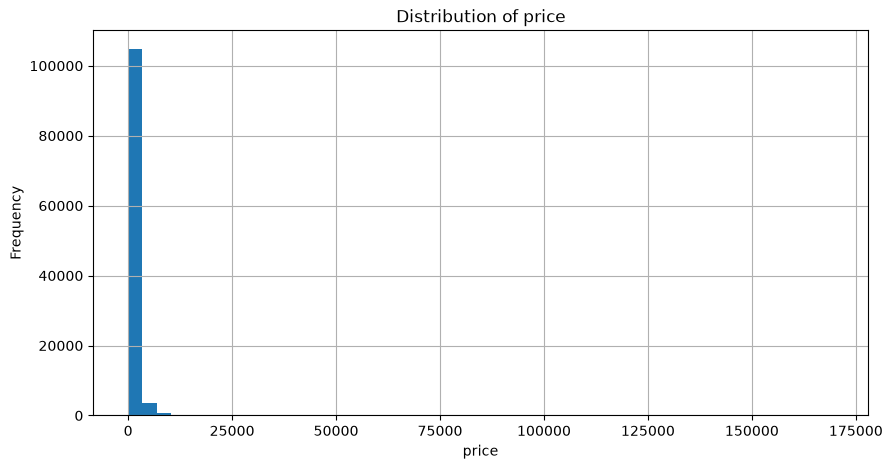

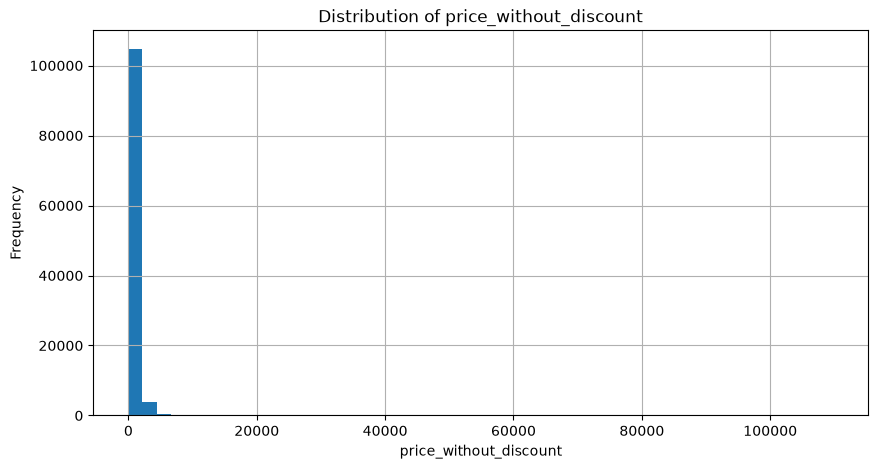

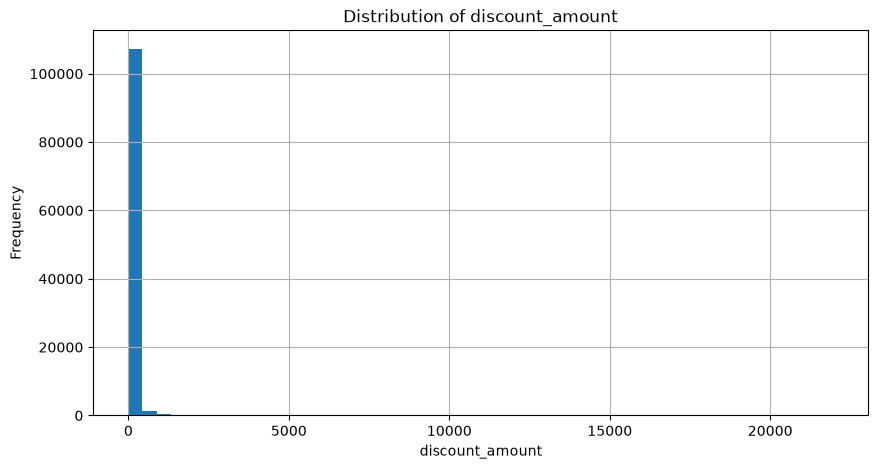

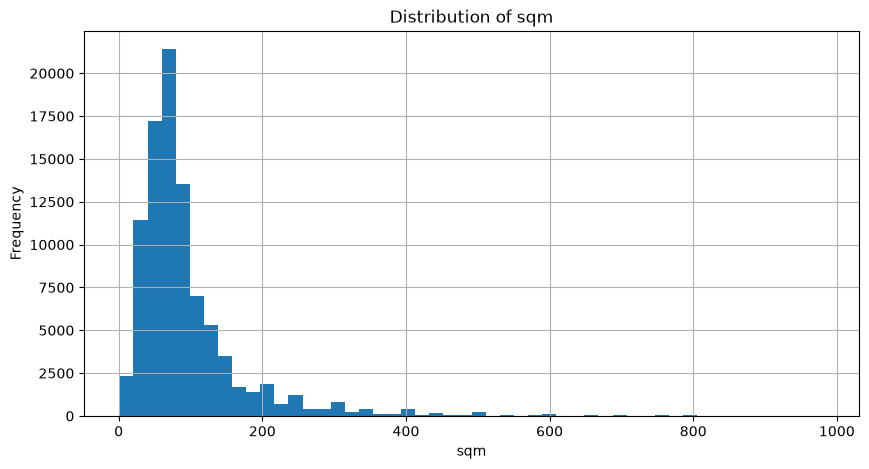

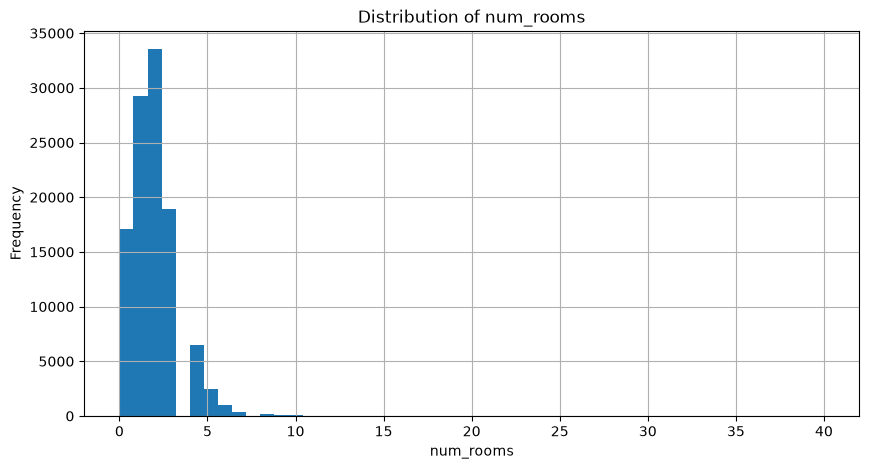

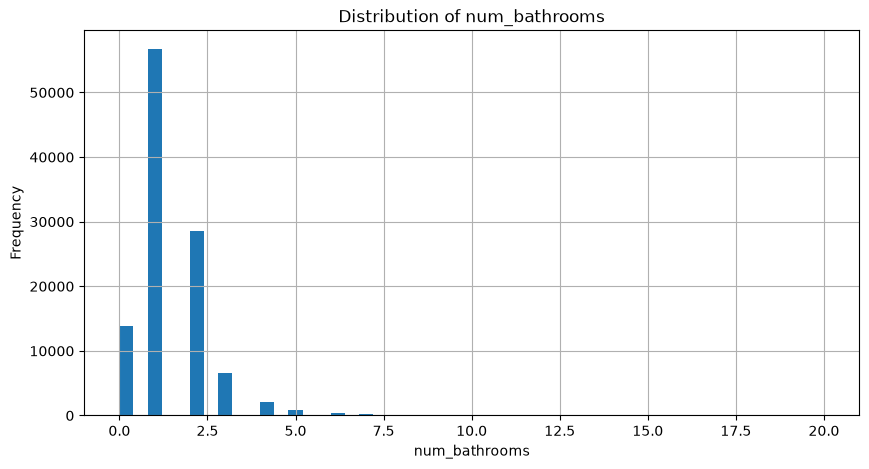

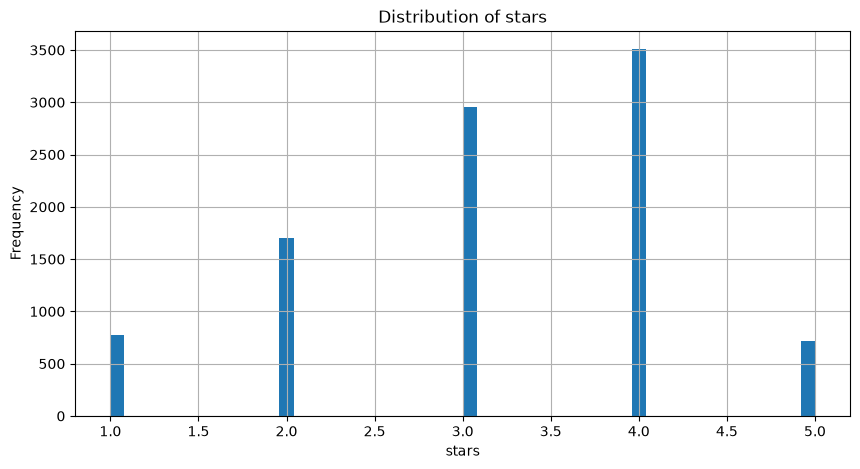

In [17]:
for var in numeric_analysis_vars:
    plt.figure(figsize=(10, 5))
    df_eda[var].hist(bins=50)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()

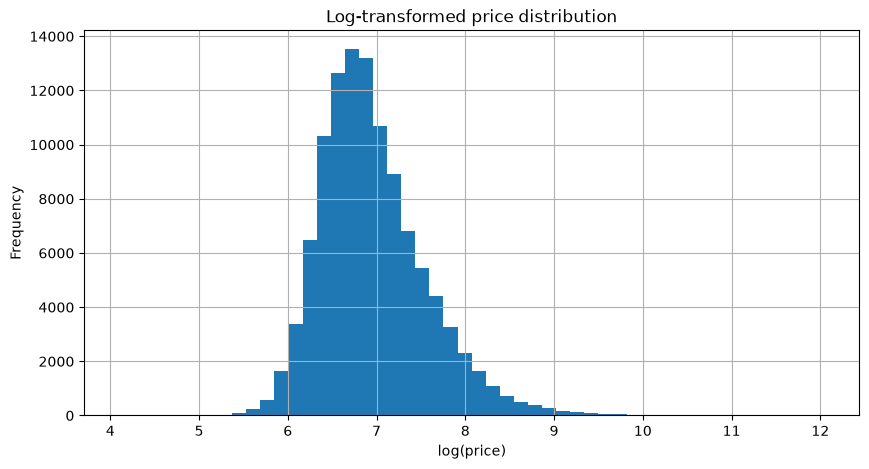

In [18]:
plt.figure(figsize=(10, 5))
np.log1p(df_eda["price"]).hist(bins=50)
plt.title("Log-transformed price distribution")
plt.xlabel("log(price)")
plt.ylabel("Frequency")
plt.show()

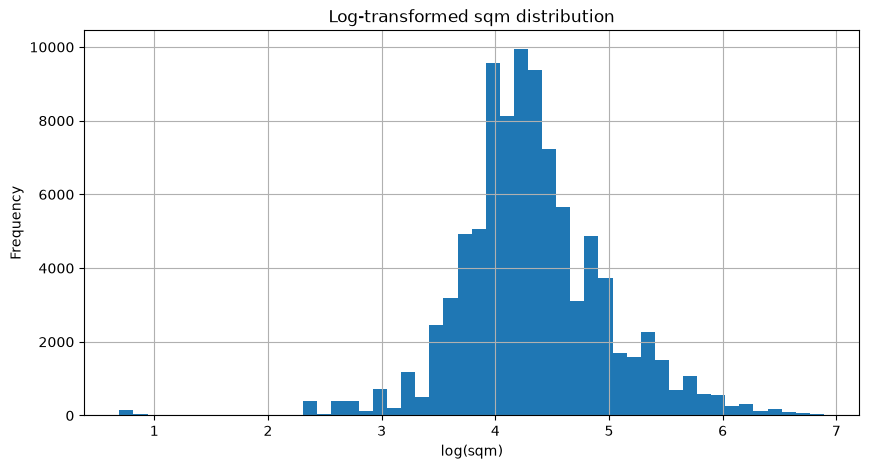

In [19]:
# sqm is as right-skewed as price -- check the log transform here too
plt.figure(figsize=(10, 5))
np.log1p(df_eda["sqm"]).hist(bins=50)
plt.title("Log-transformed sqm distribution")
plt.xlabel("log(sqm)")
plt.ylabel("Frequency")
plt.show()

C:\Users\U000000\AppData\Local\Temp\ipykernel_27000\1488342091.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_eda[var].dropna(), vert=False)


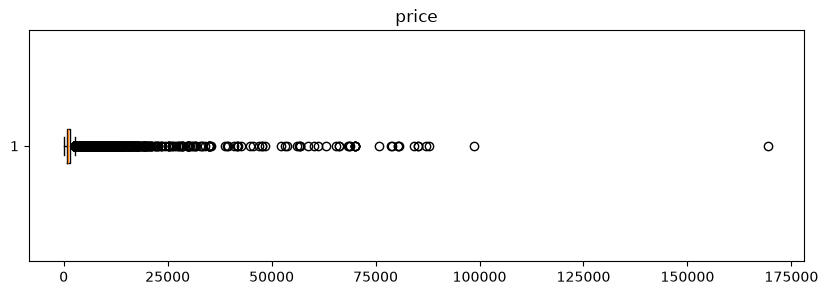

C:\Users\U000000\AppData\Local\Temp\ipykernel_27000\1488342091.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_eda[var].dropna(), vert=False)


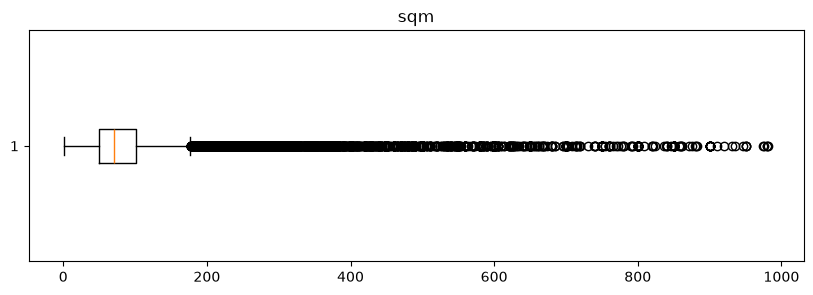

C:\Users\U000000\AppData\Local\Temp\ipykernel_27000\1488342091.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_eda[var].dropna(), vert=False)


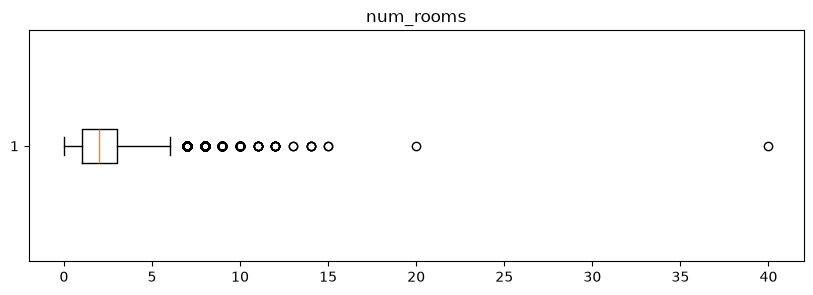

C:\Users\U000000\AppData\Local\Temp\ipykernel_27000\1488342091.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_eda[var].dropna(), vert=False)


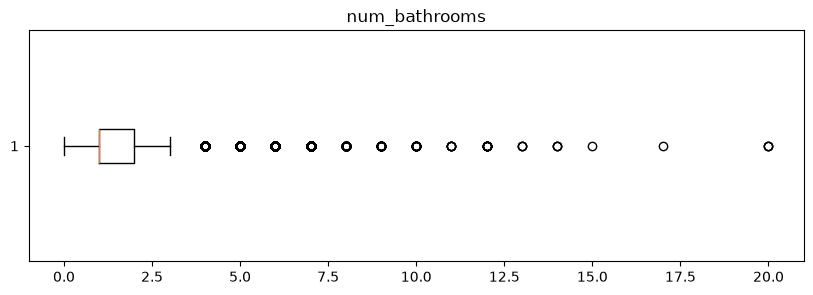

In [20]:
for var in ["price", "sqm", "num_rooms", "num_bathrooms"]:
    plt.figure(figsize=(10, 3))
    plt.boxplot(df_eda[var].dropna(), vert=False)
    plt.title(var)
    plt.show()

property_type
Apartamento                      65618
Casa o chalet                    18377
Villa                             7583
Hotel                             7156
Casa rural                        2721
Hostal o pensión                  2654
Apartahotel                       1298
Chalet de montaña                  912
Albergue                           820
Bed and breakfast                  553
Habitación en casa particular      545
Camping                            319
Agroturismo                        165
Posada u hostería                  137
Resort                             100
Tented camp                         74
Lodge                               73
Camping resort                      72
Barco                               44
Hotel cápsula                       24
Motel                               21
Love hotel                           7
Riad                                 4
Hotel básico                         2
Name: count, dtype: int64

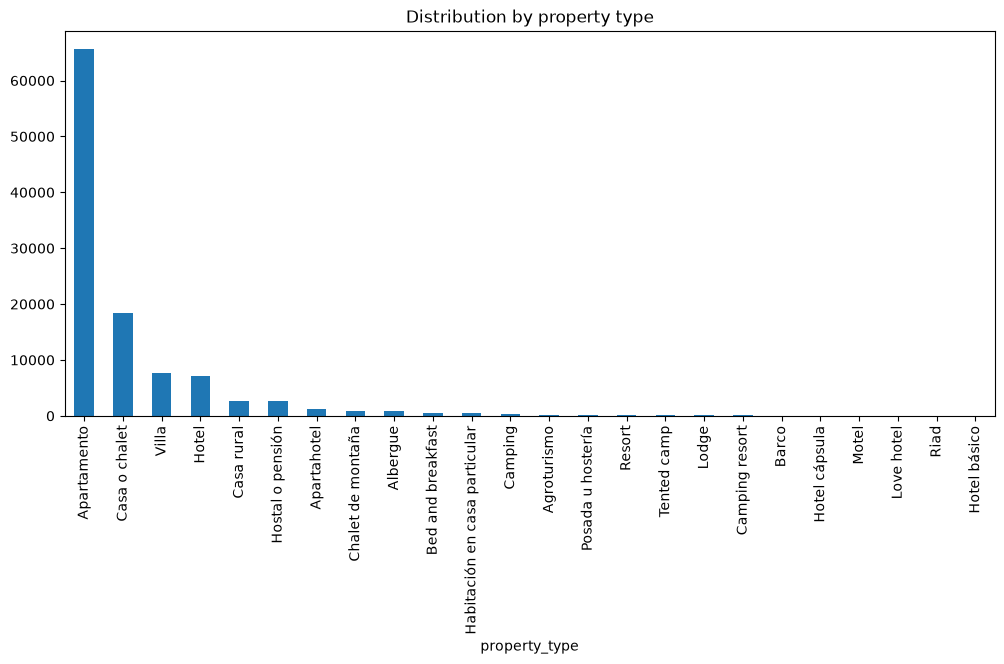

In [21]:
type_freq = df_eda["property_type"].value_counts()
display(type_freq)
type_freq.plot(kind="bar", figsize=(12, 5))
plt.title("Distribution by property type")
plt.show()

region
Andalucía                     28595
Islas Canarias                18433
Cataluña                      15277
Comunidad Valenciana          14423
Islas Baleares                 6295
Galicia                        5748
Castilla y León                3356
Comunidad de Madrid            2984
Principado de Asturias         2686
Región de Murcia               2442
Cantabria                      2089
Aragón                         1787
País Vasco                     1715
Castilla-La Mancha             1409
Extremadura                     893
Comunidad Foral de Navarra      598
La Rioja                        456
Canarias                         19
Ceuta                            19
Melilla                          11
Name: count, dtype: int64

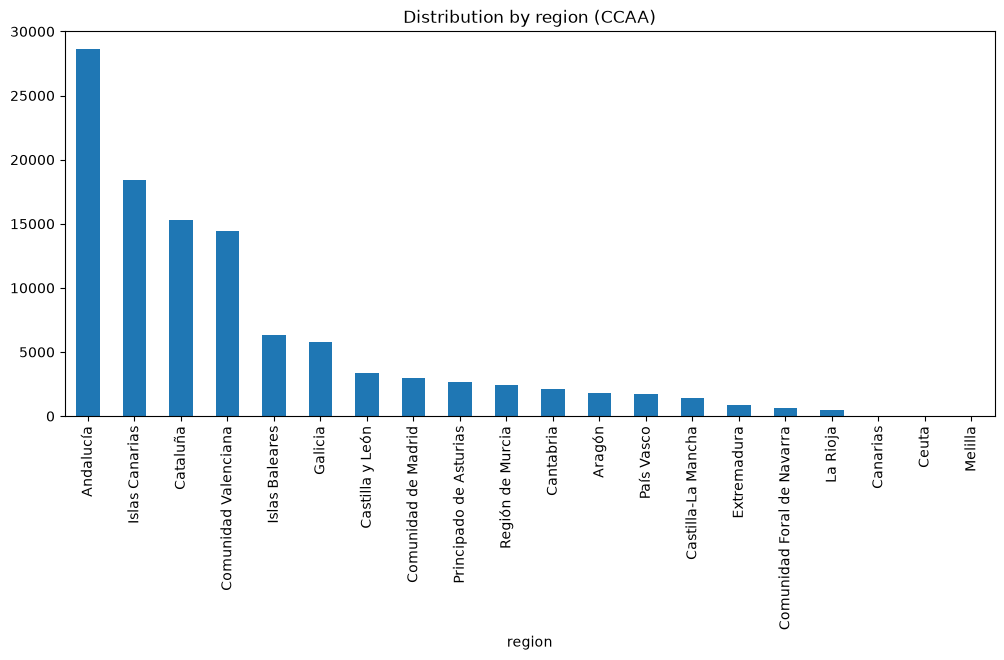

In [22]:
region_freq = df_eda["region"].value_counts()
display(region_freq)
region_freq.plot(kind="bar", figsize=(12, 5))
plt.title("Distribution by region (CCAA)")
plt.show()

province
Málaga                    13002
Alicante                   9076
Tenerife                   7879
Gerona                     6558
Cádiz                      5148
Gran Canaria               4353
Mallorca                   4255
Tarragona                  3964
Barcelona                  3591
Comunidad de Madrid        2984
Granada                    2946
Valencia                   2922
Principado de Asturias     2686
Lanzarote                  2481
Sevilla                    2457
Región de Murcia           2442
Castellón                  2425
Almería                    2357
Pontevedra                 2271
Fuerteventura              2169
Name: count, dtype: int64

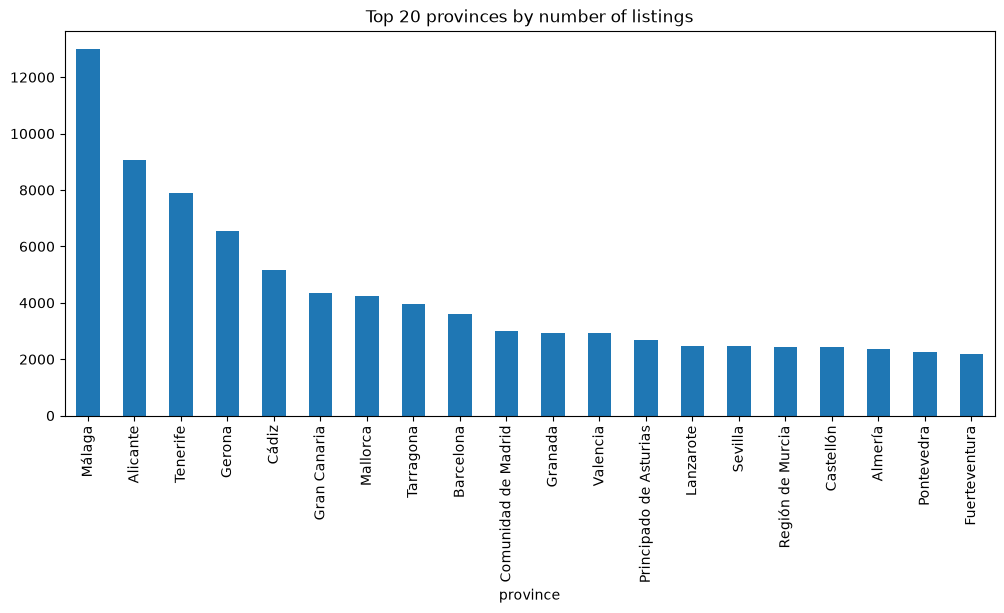

In [23]:
province_freq = df_eda["province"].value_counts().head(20)
display(province_freq)
province_freq.plot(kind="bar", figsize=(12, 5))
plt.title("Top 20 provinces by number of listings")
plt.show()

In [24]:
binary_vars = ["pool_flag", "beach_flag", "cancellation", "breakfast"]
for var in binary_vars:
    print("\n" + "=" * 60)
    print(var.upper())
    print("=" * 60)
    display(df_eda[var].value_counts(dropna=False))


POOL_FLAG


pool_flag
0    70238
1    39114
Name: count, dtype: int64


BEACH_FLAG


beach_flag
0    95069
1    14283
Name: count, dtype: int64


CANCELLATION


cancellation
1.0    64651
0.0    44647
NaN       54
Name: count, dtype: int64


BREAKFAST


breakfast
       105816
1        3482
NaN        54
Name: count, dtype: int64

In [25]:
for var in numeric_analysis_vars:
    print("\n", var)
    print("Skewness:", round(df_eda[var].skew(), 2))
    print("Kurtosis:", round(df_eda[var].kurtosis(), 2))


 price
Skewness: 24.52
Kurtosis: 1117.43

 price_without_discount
Skewness: 26.28
Kurtosis: 1801.79

 discount_amount
Skewness: 33.95
Kurtosis: 2453.86

 sqm
Skewness: 3.62
Kurtosis: 19.65

 num_rooms
Skewness: 1.22
Kurtosis: 8.46

 num_bathrooms
Skewness: 2.16
Kurtosis: 12.71

 stars
Skewness: -0.38
Kurtosis: -0.54


### Univariate analysis conclusions

- `price` is detected as right-skewed with lots of extreme values; the log transform substantially reduces this asymmetry.
- `sqm` shows the same pattern and is a candidate for a log transform as well.
- `stars` is unusable as a continuous feature given ~91% missingness; therefore we will translatee this variable into a boolean (has stars/ does not have stars) to make this variable more meaningful.
- Skewness/kurtosis confirm that tree-based methods (Isolation Forest) are relatively robust to these distributions, but LOF (distance-based) will benefit from log transforms and scaling.

## 4. Geographic Analysis

In [26]:
price_by_region = (
    df_eda.groupby("region")["price"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)
display(price_by_region)

,count,mean,median,min,max
region,,,,,
Islas Baleares,6295,2480.515659,1696.80000,295.4001,98631.8200
Comunidad de Madrid,2984,2432.492374,1966.47000,176.8000,69992.3000
País Vasco,1715,1563.321367,1187.04000,290.5000,56625.0000
Cataluña,15277,1471.507187,1074.02000,205.5200,87158.7200
Andalucía,28595,1315.293663,990.09010,94.3091,87816.9600
Cantabria,2089,1310.355233,975.50000,208.2501,18047.1500
Castilla-La Mancha,1409,1273.954374,911.56000,230.6000,15767.7273
Comunidad Valenciana,14423,1205.804619,921.25000,119.7000,80620.0000
Aragón,1787,1188.395768,945.00000,157.3000,17370.0300


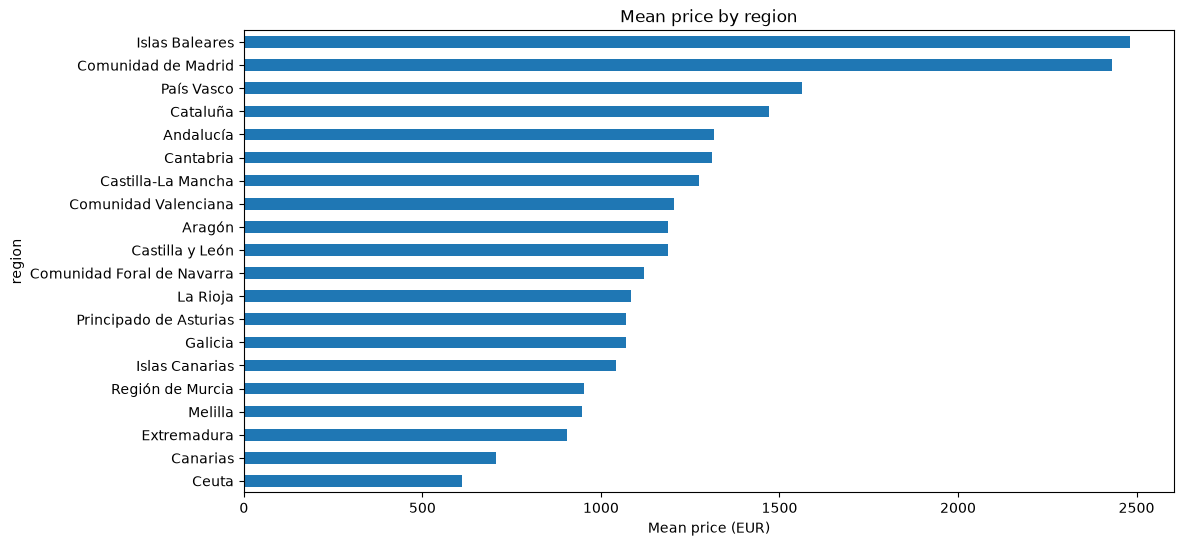

In [27]:
plt.figure(figsize=(12, 6))
price_by_region["mean"].sort_values().plot(kind="barh")
plt.title("Mean price by region")
plt.xlabel("Mean price (EUR)")
plt.show()

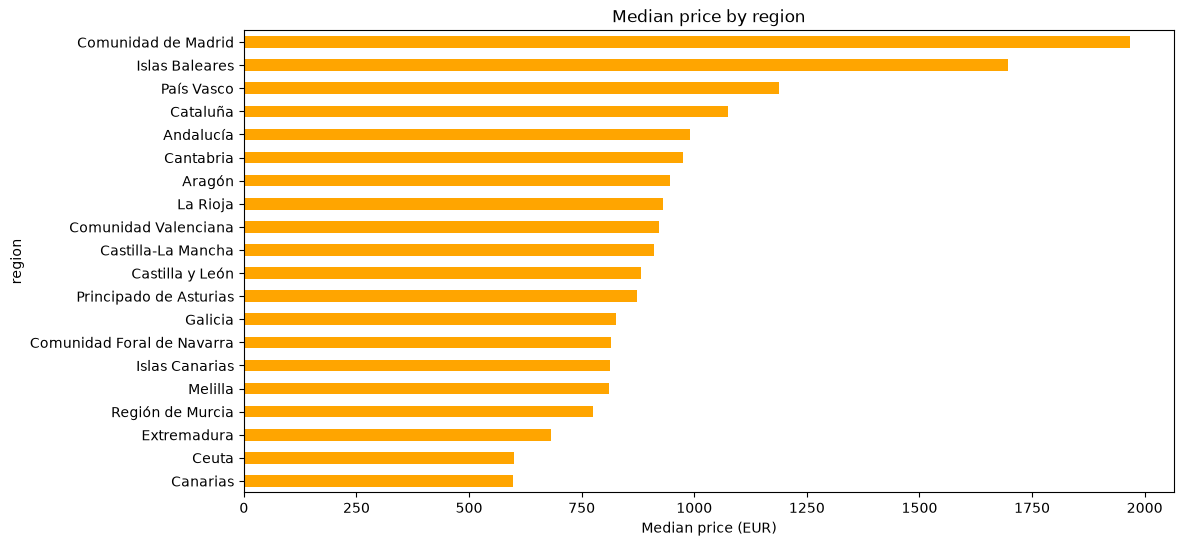

In [28]:
plt.figure(figsize=(12, 6))
price_by_region["median"].sort_values().plot(kind="barh", color="orange")
plt.title("Median price by region")
plt.xlabel("Median price (EUR)")
plt.show()

In [29]:
price_by_province = df_eda.groupby("province")["price"].agg(["count", "mean", "median"])
display(price_by_province.sort_values("mean", ascending=False).head(20))

,count,mean,median
province,,,
Ibiza y Formentera,809,4161.100533,1799.00000
Comunidad de Madrid,2984,2432.492374,1966.47000
Mallorca,4255,2427.768915,1863.38000
Barcelona,3591,2060.294585,1777.02000
Guipúzcoa,633,1863.335006,1388.95000
Segovia,336,1656.095098,1302.75000
Menorca,1231,1558.374500,1193.05000
Zaragoza,370,1541.967938,1019.07500
Málaga,13002,1523.021102,1109.91500


In [30]:
display(price_by_province.sort_values("median", ascending=False).head(20))
display(price_by_province.sort_values("median", ascending=True).head(20))

,count,mean,median
province,,,
Comunidad de Madrid,2984,2432.492374,1966.47000
Mallorca,4255,2427.768915,1863.38000
Ibiza y Formentera,809,4161.100533,1799.00000
Barcelona,3591,2060.294585,1777.02000
Guipúzcoa,633,1863.335006,1388.95000
Segovia,336,1656.095098,1302.75000
Sevilla,2457,1442.836524,1193.80000
Menorca,1231,1558.374500,1193.05000
Vizcaya,971,1397.557426,1130.00000


,count,mean,median
province,,,
El Hierro,194,670.183230,572.50000
La Gomera,427,666.837885,595.00000
Ceuta,19,612.301600,600.00000
La Palma,949,718.513775,635.00000
Badajoz,259,903.036287,635.74000
Orense,426,792.341473,700.00000
Cáceres,634,907.050051,700.76000
Castellón,2425,979.450000,720.00000
Ciudad Real,255,1088.486591,726.00000


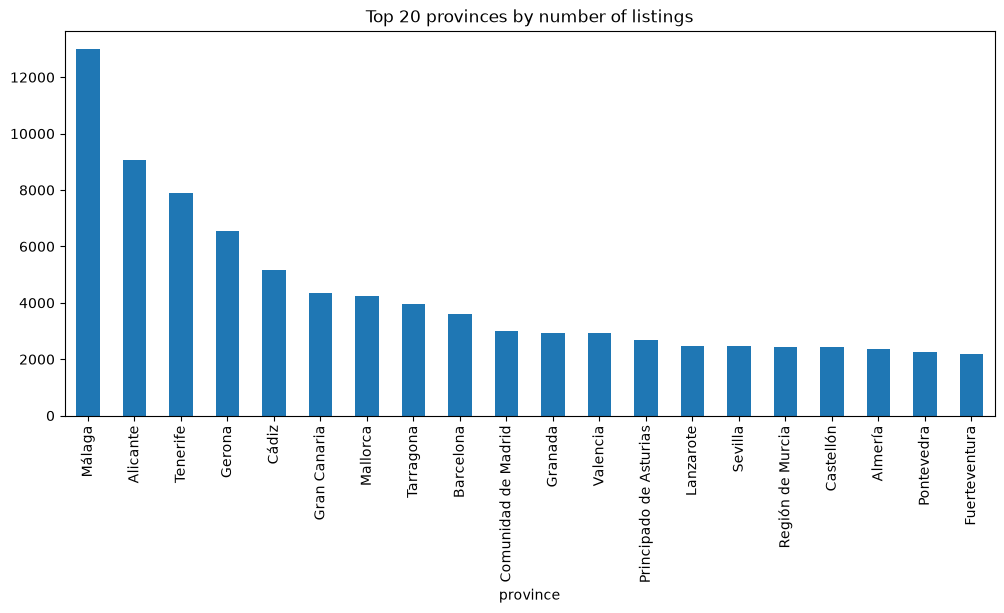

In [31]:
province_freq.plot(kind="bar", figsize=(12, 5))
plt.title("Top 20 provinces by number of listings")
plt.show()

### Geographic analysis conclusions

- Listings are geographically concentrated: Andalusia, the Canary Islands, Catalonia and Valencia dominate the volume of listings.
- Mean and median price diverge notably by region, confirming that geography must be accounted for (e.g. via `price_relative_to_province`, Section 7) so that a naturally expensive region isn't detcted as "anomalous" by the models.
- **Geographic bias risk**: regions with very few listings could have unstable local statistics (mean/median/z-scores), this will be flagged again in Section 11 (Risks).

**Note**: at this stage `region` still contains "Canarias" and "Islas Canarias" asseparate categories (same entity, inconsistent labeling). This is intentionally left unresolved here and fixed in Section 6, where all cleaning steps are grouped together.

## 5. Bivariate / Multivariate Analysis

In [32]:
df_eda["price_per_sqm"] = df_eda["price"] / df_eda["sqm"]
df_eda["price_per_sqm"].describe()

count    92449.000000
mean        30.821296
std        400.181939
min          0.855000
25%         10.070200
50%         13.823833
75%         19.541176
max      53250.093200
Name: price_per_sqm, dtype: float64

In [33]:
display(
    df_eda[["name", "property_type", "province", "sqm", "price", "price_per_sqm"]]
    .sort_values("price_per_sqm", ascending=False).head(20)
)

,name,property_type,province,sqm,price,price_per_sqm
96081,All About Villa Serenity,Villa,Málaga,1.00,53250.0932,53250.093200
84277,Mirage Ibiza,Villa,Ibiza y Formentera,1.50,78780.8000,52520.533333
28315,Villa Roca Ibiza - Un Paraíso Premium a solo 1...,Villa,Ibiza y Formentera,1.10,42000.0000,38181.818182
56410,Villa Futura Spectacular Luxury Designer Villa,Villa,Málaga,1.00,21314.1200,21314.120000
28376,Kukutana,Apartamento,Sevilla,1.00,20618.1818,20618.181800
17466,SVB Villa Volcano,Villa,Tenerife,1.00,18364.0000,18364.000000
42589,Ola Living Playa del Castell,Villa,Gerona,1.00,18227.0200,18227.020000
96008,Castle Beach House. Luxury Beachfront Villa,Villa,Málaga,1.00,17500.0000,17500.000000
35799,Chic Villa With Pool & Near Beach,Villa,Barcelona,1.00,17430.7700,17430.770000
95067,Paradisiacal Villa in Benahavís with Jacuzzi a...,Villa,Málaga,1.00,15750.0000,15750.000000


In [34]:
corr_vars = [
    "price", "price_without_discount", "discount_amount",
    "sqm", "num_rooms", "num_bathrooms", "stars", "price_per_sqm"
]

corr_pearson = df_eda[corr_vars].corr(method="pearson")
corr_spearman = df_eda[corr_vars].corr(method="spearman")

print("Pearson correlation:")
display(corr_pearson)

print("Spearman correlation:")
display(corr_spearman)

Pearson correlation:


,price,price_without_discount,discount_amount,sqm,num_rooms,num_bathrooms,stars,price_per_sqm
price,1.000000,0.307730,0.259606,0.357145,0.307750,0.359384,0.385739,0.269798
price_without_discount,0.307730,1.000000,0.843300,0.119600,0.127678,0.138569,0.204982,0.153807
discount_amount,0.259606,0.843300,1.000000,0.091935,0.099170,0.105103,0.172276,0.106528
sqm,0.357145,0.119600,0.091935,1.000000,0.651307,0.663274,0.327594,-0.046411
num_rooms,0.307750,0.127678,0.099170,0.651307,1.000000,0.772662,0.167655,0.095444
num_bathrooms,0.359384,0.138569,0.105103,0.663274,0.772662,1.000000,0.171467,0.139704
stars,0.385739,0.204982,0.172276,0.327594,0.167655,0.171467,1.000000,0.101860
price_per_sqm,0.269798,0.153807,0.106528,-0.046411,0.095444,0.139704,0.101860,1.000000


Spearman correlation:


,price,price_without_discount,discount_amount,sqm,num_rooms,num_bathrooms,stars,price_per_sqm
price,1.000000,0.131216,0.106251,0.493933,0.465164,0.483738,0.528935,0.390469
price_without_discount,0.131216,1.000000,0.994190,0.022632,0.036362,0.035309,0.127682,0.073378
discount_amount,0.106251,0.994190,1.000000,0.011008,0.024951,0.024462,0.123704,0.061866
sqm,0.493933,0.022632,0.011008,1.000000,0.741172,0.668134,0.336691,-0.528173
num_rooms,0.465164,0.036362,0.024951,0.741172,1.000000,0.760044,0.141459,-0.306891
num_bathrooms,0.483738,0.035309,0.024462,0.668134,0.760044,1.000000,0.135618,-0.209155
stars,0.528935,0.127682,0.123704,0.336691,0.141459,0.135618,1.000000,0.029570
price_per_sqm,0.390469,0.073378,0.061866,-0.528173,-0.306891,-0.209155,0.029570,1.000000


In [35]:
# Verify the price / price_without_discount / discount_amount relationship directly,
has_discount = df_eda["discount_amount"] > 0
print(f"Listings with a nonzero discount: {has_discount.sum()} ({has_discount.mean()*100:.2f}%)")
print(f"Listings with price_without_discount == 0: {(df_eda['price_without_discount'] == 0).sum()} "
      f"({(df_eda['price_without_discount'] == 0).mean()*100:.2f}%)")

Listings with a nonzero discount: 26122 (23.89%)
Listings with price_without_discount == 0: 83176 (76.06%)


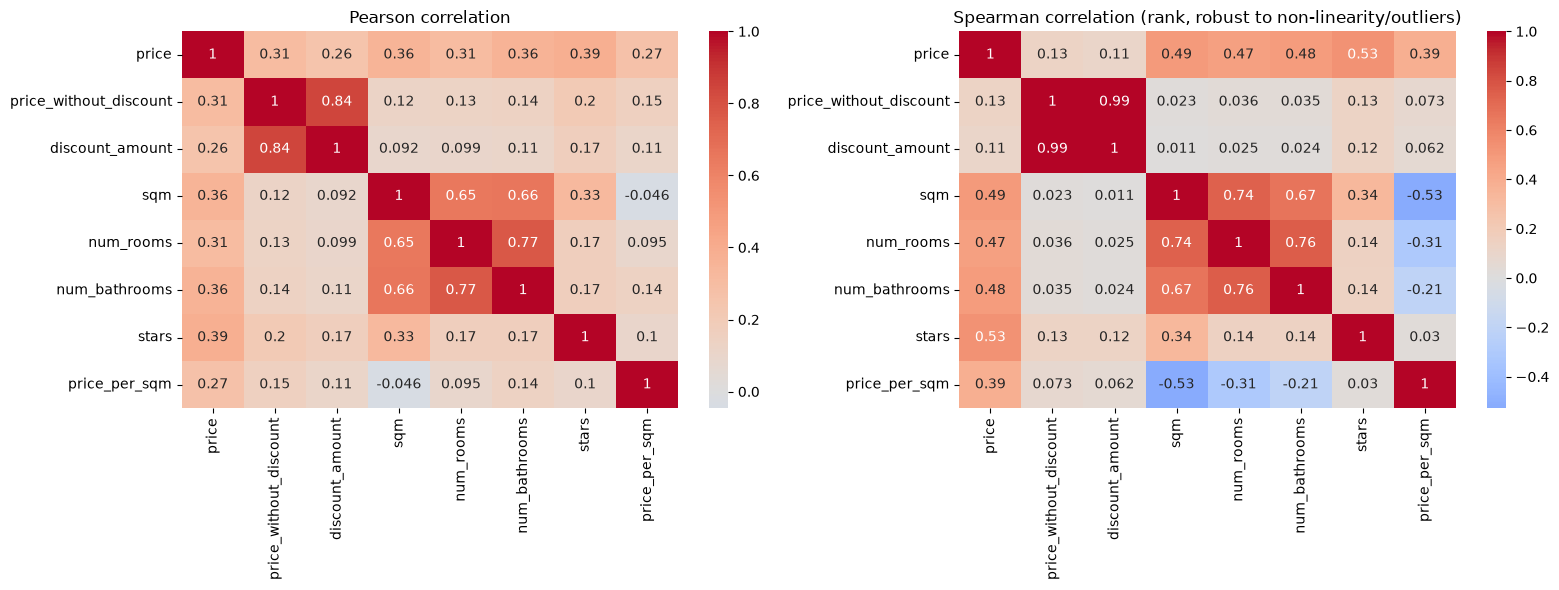

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Pearson correlation")

sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Spearman correlation (rank, robust to non-linearity/outliers)")

plt.tight_layout()
plt.show()

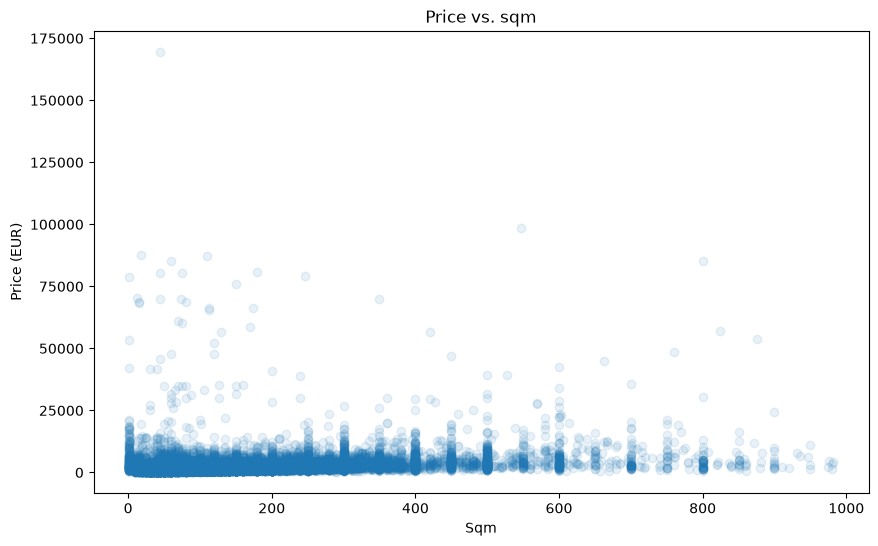

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(df_eda["sqm"], df_eda["price"], alpha=0.1)
plt.xlabel("Sqm")
plt.ylabel("Price (EUR)")
plt.title("Price vs. sqm")
plt.show()

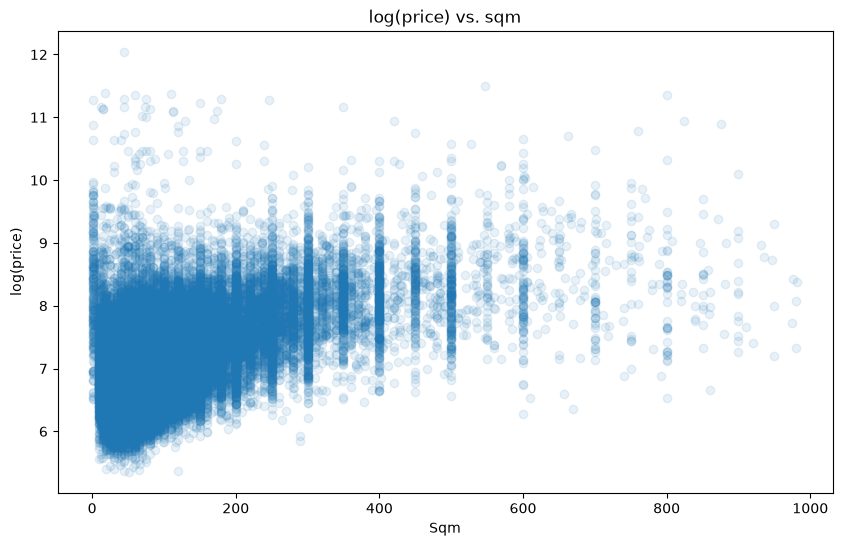

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(df_eda["sqm"], np.log1p(df_eda["price"]), alpha=0.1)
plt.xlabel("Sqm")
plt.ylabel("log(price)")
plt.title("log(price) vs. sqm")
plt.show()

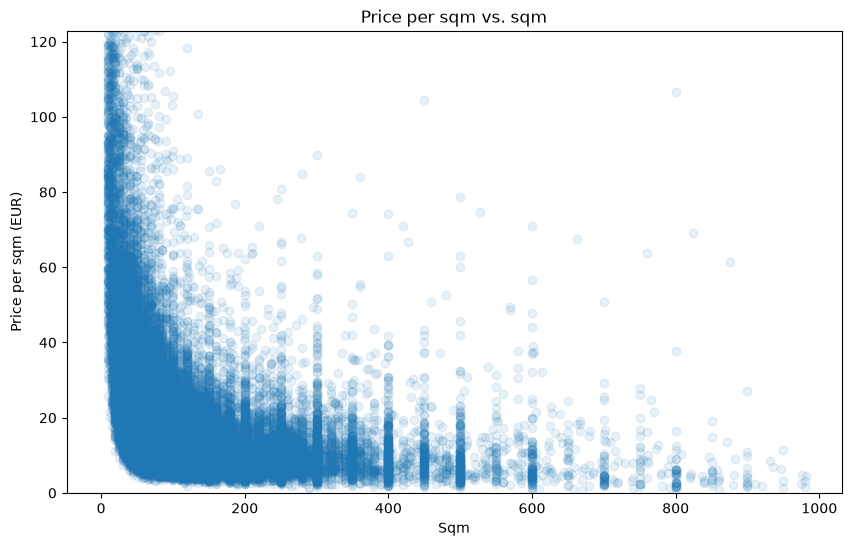

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(df_eda["sqm"], df_eda["price_per_sqm"], alpha=0.1)
plt.ylim(0, df_eda["price_per_sqm"].quantile(0.99))
plt.xlabel("Sqm")
plt.ylabel("Price per sqm (EUR)")
plt.title("Price per sqm vs. sqm")
plt.show()

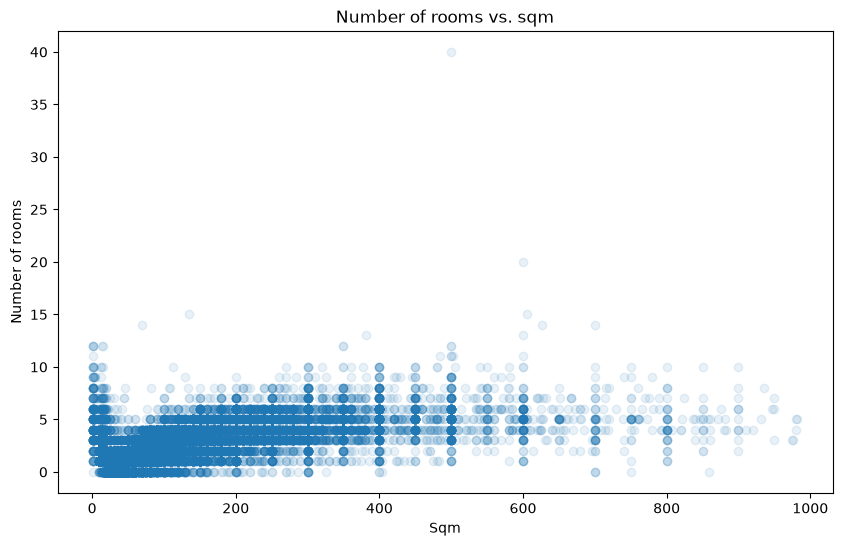

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(df_eda["sqm"], df_eda["num_rooms"], alpha=0.1)
plt.xlabel("Sqm")
plt.ylabel("Number of rooms")
plt.title("Number of rooms vs. sqm")
plt.show()

,count,mean,median
property_type,,,
Villa,7583,3165.704975,2203.80010
Chalet de montaña,912,1650.270711,1336.01005
Agroturismo,165,1465.245615,1251.98000
Casa o chalet,18377,1556.028967,1191.02000
Resort,100,1359.864806,1022.25500
Barco,44,1587.376609,967.62005
Riad,4,933.887500,961.27500
Casa rural,2721,1305.551645,939.60000
Apartahotel,1298,1110.176949,911.37005


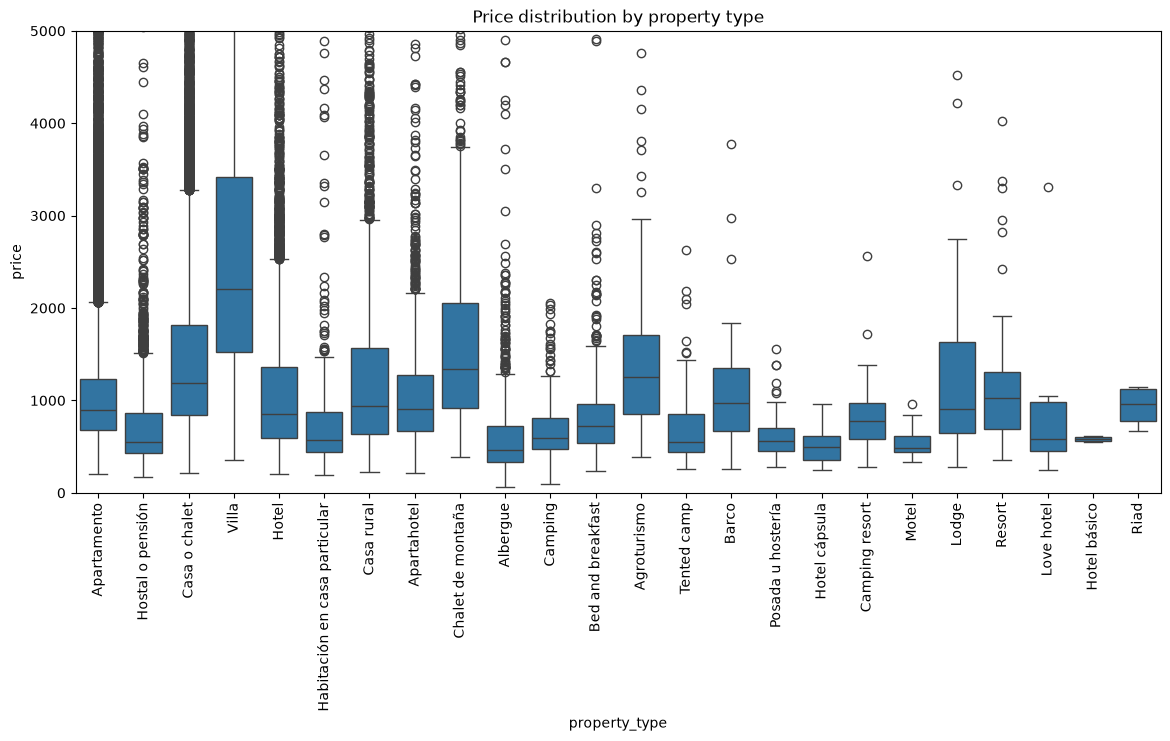

In [41]:
price_by_type = (
    df_eda.groupby("property_type")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)
display(price_by_type)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_eda, x="property_type", y="price")
plt.xticks(rotation=90)
plt.ylim(0, 5000)
plt.title("Price distribution by property type")
plt.show()

pool_flag
0     913.29505
1    1051.46000
Name: price, dtype: float64


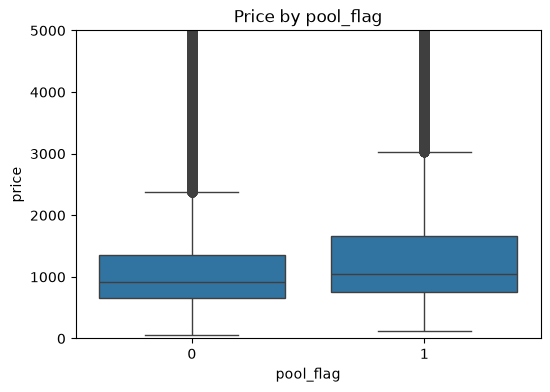

beach_flag
0    966.000
1    938.645
Name: price, dtype: float64


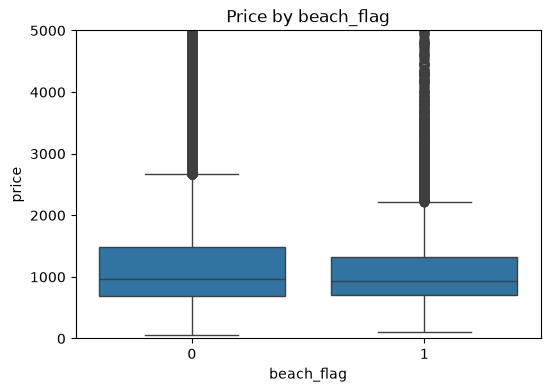

In [42]:
for flag in ["pool_flag", "beach_flag"]:
    print(df_eda.groupby(flag)["price"].median())
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_eda, x=flag, y="price")
    plt.ylim(0, 5000)
    plt.title(f"Price by {flag}")
    plt.show()

stars
1.0     547.7700
2.0     599.3000
3.0     743.0001
4.0    1113.0200
5.0    2349.9000
Name: price, dtype: float64


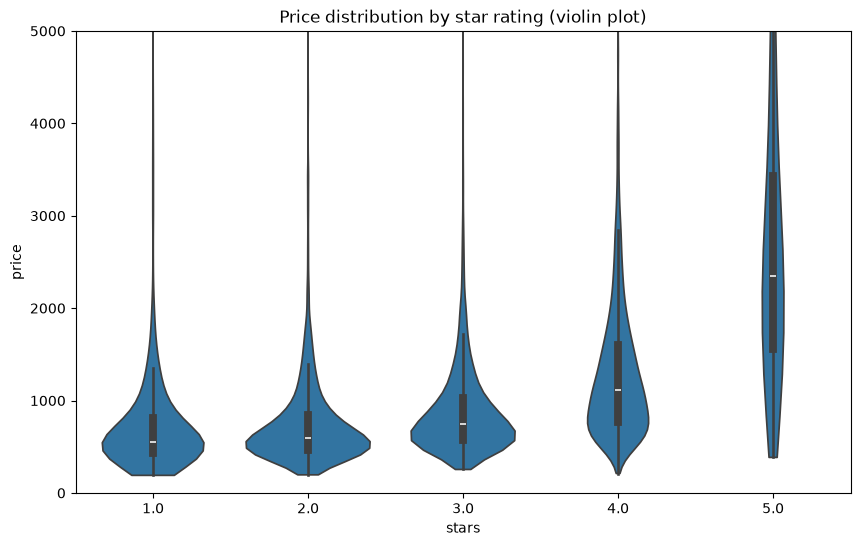

In [43]:
print(df_eda.groupby("stars")["price"].median())

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_eda.dropna(subset=["stars"]),
    x="stars", y="price", cut=0
)
plt.ylim(0, 5000)
plt.title("Price distribution by star rating (violin plot)")
plt.show()

In [44]:
df_eda["price_per_sqm"].describe(percentiles=[0.90, 0.95, 0.99, 0.999])

count    92449.000000
mean        30.821296
std        400.181939
min          0.855000
90%         29.589575
95%         41.969391
99%        122.834400
99.9%     3677.760000
max      53250.093200
Name: price_per_sqm, dtype: float64

### Bivariate / multivariate analysis conclusions

- **Price vs. sqm**: positive relationship, but with heavy dispersion for similar surface areas — expected for a mixed-type tourist market.
- **Pearson vs. Spearman**: Spearman correlations are higher than Pearson for `price`–`sqm` and `price`–`num_rooms`, confirming a *monotonic but non-linear* relationship. This matters for LOF, which is sensitive to the geometry implied by the raw scale, with the help of log transforms (Section 8) we can linearize these relationships.
- **`price_per_sqm`** is the single most extreme, heavy-tailed variable in the set and is expected to be a strong anomaly signal.
- **Property type, pool, beach and star rating** all shift the price distribution meaningfully, which are exactly the segment-level effects that`price_relative_to_type` / `price_relative_to_province` (Section 7) are designed to neutralize before anomaly detection.

### Correlation implications for modeling

- **`price` vs `price_without_discount`**: the verification cell above shows `price_without_discount` is 0 for the large majority of listings, while only a small minority currently have an active discount. Pearson/Spearman correlations between the two are therefore not very informative on their own (close to 0), but the relationship is still definitional wherever a discount exists: keeping both as model inputs risks near-duplicate/redundant features. Therefore, only `price` (or `log_price`) plus `discount_pct` should enter the final model matrix.
- **`price` vs `discount_amount`**: with so few nonzero discounts, this correlation is driven by a small subgroup. It is worthy to check discounted listings separately rather than trusting a dataset-wide correlation coefficient here (e.g. large absolute discounts concentrated on already-expensive listings).
- **`price` vs `price_per_sqm`**: may be redundant, but `price_per_sqm` normalizes for size. We will keep `price_per_sqm` and treat raw `price` as a secondary variable model feature.
- **`num_rooms` vs `sqm`**: moderate positive correlation; their *ratio* (`sqm_per_room`, Section 7) is more informative for anomaly detection than either of the variables by themselves.
- **`num_rooms` vs `num_bathrooms`**: correlated as expected (bigger properties have more of both); `baths_per_room` captures deviations from that norm.

## 6. Data Cleaning

In [45]:
df_clean = df_eda.copy()
print(df_clean.shape)

(109352, 26)


In [46]:
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
rows_after = len(df_clean)

print(f"Rows removed: {rows_before - rows_after}")
print(f"New shape: {df_clean.shape}")

Rows removed: 716
New shape: (108636, 26)


**Duplicate removal**: 716 exact duplicate records (detected during the quality audit) were removed. Since these rows were identical across every variable, they were treated as artifacts of the scraping process rather than genuine repeate observations.

In [47]:
df_clean["region"] = df_clean["region"].replace({"Canarias": "Canary Islands", "Islas Canarias": "Canary Islands"})
df_clean["region"].value_counts()

region
Andalucía                     28553
Canary Islands                18452
Cataluña                      15092
Comunidad Valenciana          14096
Islas Baleares                 6295
Galicia                        5748
Castilla y León                3280
Comunidad de Madrid            2984
Principado de Asturias         2671
Región de Murcia               2437
Cantabria                      2089
Aragón                         1781
País Vasco                     1681
Castilla-La Mancha             1386
Extremadura                     891
Comunidad Foral de Navarra      598
La Rioja                        455
Ceuta                            19
Melilla                          11
Name: count, dtype: int64

**Category homogenization**: the `region` variable contained two labels for the same entity ("Canarias" / "Islas Canarias"). These are unified into a single category.

In [48]:
constant_vars = ["capacity", "current_date", "checkin_date", "checkout_date"]
df_clean = df_clean.drop(columns=constant_vars)
df_clean.shape

(108636, 22)

**Removal of constant variables**: `capacity`, `current_date`, `checkin_date` and `checkout_date` take a single value across the entire dataset. A feature with zero variance carries no discriminative power for either Isolation Forest or LOF and adds only noise/cost.

In [49]:
(df_clean.isnull().mean().sort_values(ascending=False) * 100)

stars                     91.175117
sqm                       15.453441
price_per_sqm             15.453441
province                   0.107699
region                     0.107699
locality                   0.107699
municipality               0.107699
property_type              0.067197
breakfast                  0.049707
price                      0.049707
location_id                0.049707
num_bathrooms              0.049707
discount_amount            0.049707
num_rooms                  0.049707
cancellation               0.049707
price_without_discount     0.049707
name                       0.017490
id                         0.000000
room_id                    0.000000
room_name                  0.000000
pool_flag                  0.000000
beach_flag                 0.000000
dtype: float64

In [50]:
df_clean["breakfast"] = (
    df_clean["breakfast"]
    .fillna("")
    .astype(str)
    .str.strip()
    .map({"1": 1})
    .fillna(0)
    .astype(int)
)
df_clean["breakfast"].value_counts(dropna=False)

breakfast
0    105159
1      3477
Name: count, dtype: int64

**`breakfast` treatment**: the raw variable only ever appeared as blank or `"1"`,
with 48 nulls tied to otherwise-incomplete records. It was recoded as an explicit
binary flag (1 = breakfast included, 0 = not stated / not included), which is directly
usable by both models without further encoding.

In [51]:
df_clean.isnull().sum().sort_values(ascending=False)

stars                     99049
sqm                       16788
price_per_sqm             16788
province                    117
region                      117
locality                    117
municipality                117
property_type                73
cancellation                 54
price                        54
location_id                  54
num_bathrooms                54
discount_amount              54
num_rooms                    54
price_without_discount       54
name                         19
id                            0
room_name                     0
room_id                       0
pool_flag                     0
beach_flag                    0
breakfast                     0
dtype: int64

In [52]:
rows_before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=["price", "num_rooms", "num_bathrooms"])
rows_after = df_clean.shape[0]

print(f"Rows removed: {rows_before - rows_after}")
print(f"New shape: {df_clean.shape}")


Rows removed: 54
New shape: (108582, 22)


In [53]:
# Remove records with no geographic information
rows_before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=["region", "province"])
rows_after = df_clean.shape[0]

print(f"Rows removed: {rows_before - rows_after}")
print(f"New shape: {df_clean.shape}")

Rows removed: 63
New shape: (108519, 22)


In [54]:
# 1. Delete data errors (sqm < 10), keeping null
rows_before = df_clean.shape[0]
df_clean = df_clean[(df_clean['sqm'] >= 10) | (df_clean['sqm'].isna())]
rows_after_filter = df_clean.shape[0]

print(f"Data errors (sqm < 10) deleted: {rows_before - rows_after_filter}")

# 2. Imput values for null (median)
df_clean['sqm'] = df_clean.groupby(['province', 'property_type'])['sqm'].transform(lambda x: x.fillna(x.median()))

# 3. Backup input (for null medians)
df_clean['sqm'] = df_clean.groupby(['property_type'])['sqm'].transform(lambda x: x.fillna(x.median()))

# 4. Delete rest of nulls
df_clean = df_clean.dropna(subset=['sqm'])
rows_final = df_clean.shape[0]

print(f"Rest of nulls deleted: {rows_after_filter - rows_final}")
print(f"New shape: {df_clean.shape}")

Data errors (sqm < 10) deleted: 256
Rest of nulls deleted: 140
New shape: (108123, 22)


In [55]:
display(df_clean.head())

,id,name,room_id,room_name,location_id,region,province,municipality,locality,property_type,num_rooms,num_bathrooms,sqm,pool_flag,beach_flag,stars,price,discount_amount,price_without_discount,breakfast,cancellation,price_per_sqm
0,10000125,Apartamentos Villa Zoila Nigrán,1000012502,Apartamento de 1 dormitorio,-394030.0,Galicia,Pontevedra,Nigrán,Nigrán,Apartamento,1.0,1.0,55.0,0,1,NaN,1117.24,99.56,1216.8,0,0.0,20.313455
1,10000734,Hostal Carlos III,1000073405,Habitación Deluxe - 1 cama grande,-398093.0,Andalucía,Córdoba,"Victoria, La",Aldea Quintana,Hostal o pensión,0.0,0.0,45.0,0,0,NaN,420.00,0.00,0.0,0,1.0,NaN
2,10001085,Vive tu vida soñada delante del mar,1000108501,Apartamento de 2 dormitorios,-386902.0,Cataluña,Gerona,"Escala, L'",L'Escala,Apartamento,2.0,1.0,175.0,0,1,NaN,1080.02,0.00,0.0,0,0.0,6.171543
3,1000112,La Vista de Medina By La Vista Medina Stays,100011202,Estudio,-391732.0,Andalucía,Cádiz,Medina-Sidonia,Medina Sidonia,Apartamento,1.0,1.0,25.0,1,0,2.0,630.00,0.00,0.0,0,1.0,25.200000
4,1000115,Hostal Catalina de Austria,100011502,Habitación Doble - 2 camas,-404562.0,Castilla y León,Palencia,Torquemada,Torquemada,Hostal o pensión,0.0,0.0,45.0,0,0,2.0,418.00,0.00,0.0,0,1.0,NaN


### Cleaning conclusions

- **Duplicates**: 716 exact duplicates removed.
- **Homogenization**: geographic category inconsistencies (region naming) resolved.
- **Constants**: zero-variance columns dropped.
- **Missing critical fields**: rows missing `price`, `num_rooms`, `num_bathrooms`, `region` or `province` were dropped, since these are core anomaly-detection features that cannot be safely imputed without risking synthetic, non-representative anomalies.
- `stars` is deliberately **not** dropped or imputed here (see Section 7/8), where it will be reframed as a `has_stars` binary flag instead of discarding the information.
- 396 rows deleted due to square meter inconsistencies (less than 10 square meters and nulls after input values)

## 7. Feature Engineering

In [56]:
# Before building room/bathroom ratios, check whether num_rooms == 0 / num_bathrooms == 0
print("=" * 60)
print("num_rooms == 0 BY PROPERTY TYPE")
print("=" * 60)
display(
    pd.crosstab(df_clean["property_type"], df_clean["num_rooms"] == 0, normalize="index")
    .round(2).sort_values(True, ascending=False)
)

print("=" * 60)
print("num_bathrooms == 0 BY PROPERTY TYPE")
print("=" * 60)
display(
    pd.crosstab(df_clean["property_type"], df_clean["num_bathrooms"] == 0, normalize="index")
    .round(2).sort_values(True, ascending=False)
)

num_rooms == 0 BY PROPERTY TYPE


num_rooms,False,True
property_type,,
Albergue,0.02,0.98
Posada u hostería,0.02,0.98
Hostal o pensión,0.05,0.95
Hotel,0.05,0.95
Bed and breakfast,0.07,0.93
Habitación en casa particular,0.13,0.87
Love hotel,0.29,0.71
Agroturismo,0.43,0.57
Lodge,0.44,0.56


num_bathrooms == 0 BY PROPERTY TYPE


num_bathrooms,False,True
property_type,,
Albergue,0.02,0.98
Posada u hostería,0.04,0.96
Hotel,0.05,0.95
Hostal o pensión,0.06,0.94
Bed and breakfast,0.09,0.91
Habitación en casa particular,0.15,0.85
Love hotel,0.29,0.71
Lodge,0.50,0.50
Resort,0.50,0.50


Both `num_rooms == 0` and `num_bathrooms == 0` concentrate in `Hostal o pensión`, `Habitación en casa particular`, `Hotel` and similar single-room-booking types. This is consistent with `num_rooms`/`num_bathrooms` counting *additional* rooms/bathrooms beyond the one being booked, rather than an error (a single hostel room legitimately has "0 extra rooms"). Treating these as missing could silently drop ~19% of the dataset when building ratio features below. Instead, we will use `np.maximum(x, 1)`, which treats 0 as 1 (the unit itself) without discarding the record.

In [57]:
df_clean["price_per_sqm"] = df_clean["price"] / df_clean["sqm"]

In [58]:
df_clean["discount_pct"] = np.where(
    df_clean["price"] > 0,
    df_clean["discount_amount"] / df_clean["price"],
    0
)

In [59]:
df_clean["sqm_per_room"] = df_clean["sqm"] / np.maximum(df_clean["num_rooms"], 1)

In [60]:
df_clean["baths_per_room"] = df_clean["num_bathrooms"] / np.maximum(df_clean["num_rooms"], 1)

In [61]:
df_clean["price_per_room"] = df_clean["price"] / np.maximum(df_clean["num_rooms"], 1)

In [62]:
# Price per bathroom
df_clean["price_per_bath"] = df_clean["price"] / np.maximum(df_clean["num_bathrooms"], 1)

# Rooms per sqm
df_clean["rooms_per_sqm"] = np.where(
    df_clean["sqm"] > 0,
    df_clean["num_rooms"] / df_clean["sqm"],
    np.nan
)

# How many standard deviations away from the mean price of its own property type / province.
df_clean["price_zscore_by_type"] = (
    df_clean.groupby("property_type")["price"]
    .transform(lambda s: (s - s.mean()) / s.std())
)

df_clean["price_zscore_by_province"] = (
    df_clean.groupby("province")["price"]
    .transform(lambda s: (s - s.mean()) / s.std())
)

# Price relative to the median of its own segment
df_clean["price_relative_to_type"] = (
    df_clean["price"]
    / df_clean.groupby("property_type")["price"].transform("median")
)

df_clean["price_relative_to_province"] = (
    df_clean["price"]
    / df_clean.groupby("province")["price"].transform("median")
)

# has_stars: 1 if it has a star rating, 0 if it does not
df_clean["has_stars"] = df_clean["stars"].notna().astype(int)

new_engineered_vars = [
    "price_per_bath", "rooms_per_sqm",
    "price_zscore_by_type", "price_zscore_by_province",
    "price_relative_to_type", "price_relative_to_province",
    "has_stars"
]
display(df_clean[new_engineered_vars].describe())

,price_per_bath,rooms_per_sqm,price_zscore_by_type,price_zscore_by_province,price_relative_to_type,price_relative_to_province,has_stars
count,108123.000000,108123.000000,1.081230e+05,1.081230e+05,108123.000000,108123.000000,108123.000000
mean,924.415597,0.024033,3.890396e-17,2.523500e-17,1.298721,1.299978,0.088612
std,1293.105923,0.027477,9.999168e-01,9.997317e-01,1.768456,1.780096,0.284184
min,59.500200,0.000000,-1.260012e+00,-1.771996e+00,0.128788,0.062963,0.000000
25%,558.107500,0.015385,-3.174407e-01,-3.611392e-01,0.744472,0.751228,0.000000
50%,752.120000,0.022727,-1.667782e-01,-1.774403e-01,1.000000,1.000000,0.000000
75%,1044.867500,0.030000,8.253495e-02,7.610954e-02,1.436056,1.401988,0.000000
max,169490.000000,0.857143,1.060782e+02,6.350099e+01,189.745312,206.272515,1.000000


In [63]:
derived_vars = [
    "price_per_sqm", "discount_pct", "sqm_per_room",
    "baths_per_room", "price_per_room"
]
display(df_clean[derived_vars].describe())

,price_per_sqm,discount_pct,sqm_per_room,baths_per_room,price_per_room
count,108123.000000,108123.000000,108123.000000,108123.000000,108123.000000
mean,19.516983,0.032101,45.900615,0.713805,749.081475
std,43.249205,0.084837,29.953256,0.432695,1157.530254
min,0.434000,0.000000,1.166667,0.000000,59.500200
25%,10.063932,0.000000,32.000000,0.500000,413.000000
50%,14.000001,0.000000,40.000000,0.666667,582.500000
75%,20.322582,0.000000,50.000000,1.000000,843.082500
max,5843.335000,2.439526,859.000000,15.000000,169490.000000


In [64]:
display(
    df_clean[["name", "property_type", "price", "num_rooms", "price_per_room"]]
    .sort_values("price_per_room", ascending=False).head(20)
)

,name,property_type,price,num_rooms,price_per_room
10924,Triana Cool Studio,Apartamento,169490.0000,0.0,169490.00000
108817,Maravilloso piso con piscina a 200m de la playa,Apartamento,85158.7201,1.0,85158.72010
17921,Apartamento 1 habitacion 450m playa Baltar-VUT,Apartamento,80491.9500,1.0,80491.95000
95100,2 min walk to Cove Finestrat - Terrace - Pool,Apartamento,70110.0000,1.0,70110.00000
78557,Can Serol Apartaments,Apartamento,70023.8000,1.0,70023.80000
86242,Casa Rural Cal Farragetes,Hostal o pensión,70006.8600,0.0,70006.86000
55322,Espacio Rural La Cabaña de Miraflores,Casa o chalet,69992.3000,1.0,69992.30000
81516,Cal Gabriel,Casa rural,63020.7200,0.0,63020.72000
13205,Sea View Apartment Sabbia Valencia,Apartamento,60270.0000,1.0,60270.00000
102767,Apartamentos Rous - Solo adultos,Hotel,56000.0000,0.0,56000.00000


In [65]:
display(
    df_clean[["name", "property_type", "sqm", "num_rooms", "sqm_per_room"]]
    .sort_values("sqm_per_room", ascending=False).head(20)
)

,name,property_type,sqm,num_rooms,sqm_per_room
39753,Villa Ariel,Casa o chalet,859.0,0.0,859.0
3634,"Casita con piscina cerca de Chinchón, Aranjuez...",Casa o chalet,800.0,1.0,800.0
25654,Villa Fernando 12 personas 8km Lloret de Mar,Villa,800.0,1.0,800.0
43662,Finca roxana,Villa,800.0,1.0,800.0
57993,Villa moderna con vista panorámica y piscina -...,Villa,750.0,0.0,750.0
24419,Casa del Sol,Casa o chalet,750.0,1.0,750.0
57060,Villa lujo con vista al mar - 10 pers. - ES-17...,Villa,700.0,0.0,700.0
2613,Sa Punta Negra,Casa o chalet,700.0,0.0,700.0
83437,La Casa Grande de Adolfo,Casa rural,700.0,0.0,700.0
33019,Disfrutar de las rias baixas,Villa,600.0,1.0,600.0


### Feature engineering conclusions

**Original derived variables** `price_per_sqm`, `discount_pct`, `sqm_per_room`, `baths_per_room`, `price_per_room`: capture relationships between raw attributes that are more informative in combination rather than in isolation.

**New variables added in this review**:

| Variable | Use for anomaly detection |
|---|---|
| `price_per_bath` | Identifies properties whose price is unusually high or low relative to the number of bathrooms, regardless of the total number of rooms |
| `rooms_per_sqm` | Captures unusually overcrowded properties by measuring how many rooms are packed into the available living space |
| `price_zscore_by_type` / `price_zscore_by_province` |  Highlights listings that are unusually expensive or cheap compared with similar properties in the same property type or province |
| `price_relative_to_type` / `price_relative_to_province` | Measures how a property's price compares to its local market benchmark, making it easier to spot listings that deviate from typical market behavior |
| `has_stars` | Recovers signal from a 91%-missing variable instead of  directly discarding `stars` |

The two most valuable additions for the modeling stage are the **segment-relative variables** (`price_zscore_by_*`, `price_relative_to_*`): raw price and raw `price_per_sqm` conflate "this listing is unusual" with "this region/type is naturally expensive." Segment-relative features are able to separate those two effects, which is essential since Isolation Forest and LOF have no built-in concept of subgroup context.

## 8. Variable Treatment and Transformations

We have to make some decisions on how each problematic variable should enter the models.

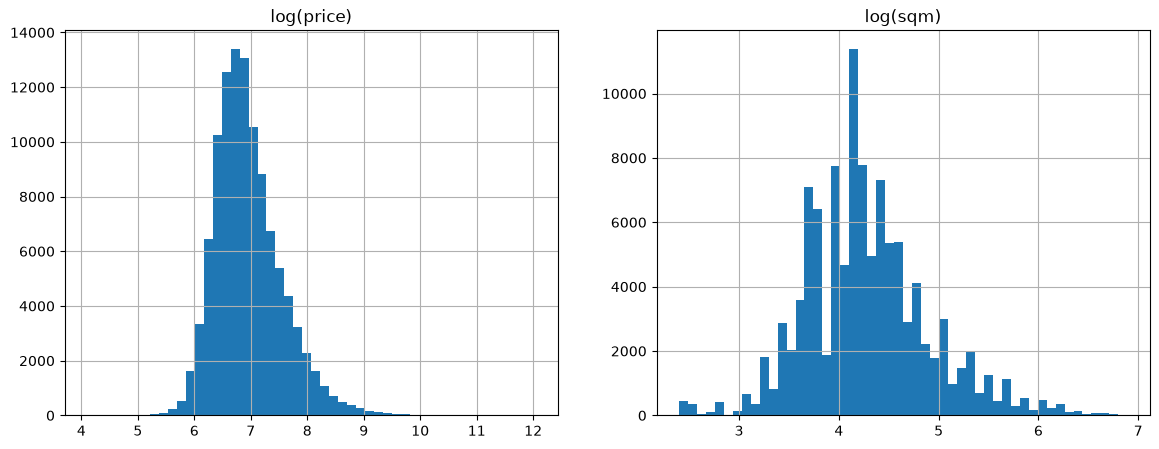

In [66]:
df_clean["log_price"] = np.log1p(df_clean["price"])
df_clean["log_sqm"] = np.log1p(df_clean["sqm"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_clean["log_price"].hist(bins=50, ax=axes[0])
axes[0].set_title("log(price)")
df_clean["log_sqm"].hist(bins=50, ax=axes[1])
axes[1].set_title("log(sqm)")
plt.show()

- **`price`** → we are going to apply `log1p`. Strong right skew (which was already confirmed by skewness/kurtosis in Section 3).
- **`sqm`** → we are applying `log1p` for the same reason (reduces the leverage of a few extremely large properties (villas, fincas) on distance-based methods).
- **`discount_amount`** → we will not use the raw amount, but`discount_pct` instead (already engineered in Section 7). A percentage is comparable across price ranges, while the absolute discount is trivially correlated with `price` itself and would duplicate that signal rather than add new information.
- **`stars`** → we will not feed the (91%-missing) numeric variable into the models. Moreover, we computed `has_stars` as the model input.

## 9. Preliminary Anomaly Detection (Business Rules)

Before any unsupervised model is trained, simple domain rules are used to get a first read on which records may look suspicious. This also acts as a sanity check for the later Isolation Forest / LOF results.

In [67]:
flags = pd.DataFrame(index=df_clean.index)

# Extreme price
q1, q3 = df_clean["price"].quantile([0.25, 0.75])
iqr = q3 - q1
flags["extreme_price_high"] = df_clean["price"] > (q3 + 3 * iqr)

# Extremely low price
flags["extreme_price_low"] = df_clean["price"] < df_clean["price"].quantile(0.01)

# Suspected placeholder sqm values
flags["suspected_placeholder_sqm"] = df_clean["sqm"] <= 2

# Extreme price per sqm
q1m, q3m = df_clean["price_per_sqm"].quantile([0.25, 0.75])
iqrm = q3m - q1m
flags["extreme_price_per_sqm"] = df_clean["price_per_sqm"] > (q3m + 3 * iqrm)

# Many rooms for very little space
flags["overcrowded_layout"] = df_clean["rooms_per_sqm"] > df_clean["rooms_per_sqm"].quantile(0.995)

# Many bathrooms relative to rooms
flags["excess_bathrooms"] = df_clean["baths_per_room"] > df_clean["baths_per_room"].quantile(0.995)

# Tiny villas / houses
large_property_types = ["Villa", "Casa o chalet"]
flags["tiny_villa"] = (
    df_clean["property_type"].isin(large_property_types) & (df_clean["sqm"] < 30)
)

# Extremely large apartments/studios
small_property_types = ["Apartamento", "Estudio"]
flags["huge_apartment"] = (
    df_clean["property_type"].isin(small_property_types) & (df_clean["sqm"] > 300)
)

flags["any_flag"] = flags.any(axis=1)

print("=" * 60)
print("BUSINESS-RULE FLAG SUMMARY")
print("=" * 60)
display(flags.drop(columns="any_flag").sum().to_frame("n_records"))
print(f"\nTotal records flagged by at least one rule: {flags['any_flag'].sum()} "
      f"({flags['any_flag'].mean() * 100:.2f}%)")

BUSINESS-RULE FLAG SUMMARY


,n_records
extreme_price_high,3542
extreme_price_low,1081
suspected_placeholder_sqm,0
extreme_price_per_sqm,4338
overcrowded_layout,484
excess_bathrooms,402
tiny_villa,814
huge_apartment,63



Total records flagged by at least one rule: 8556 (7.91%)


In [68]:
df_clean = df_clean.join(flags)

display(
    df_clean[df_clean["any_flag"]]
    [["name", "property_type", "province", "sqm", "price", "price_per_sqm"]]
    .head(20)
)

,name,property_type,province,sqm,price,price_per_sqm
6,"Luxury Villa Alma Pool, Garden & Parking",Villa,Málaga,500.0,10049.9491,20.099898
10,Dalí,Casa o chalet,Gerona,150.0,3294.0200,21.960133
34,Castilla Termal Brihuega,Hotel,Guadalajara,38.0,2388.0000,62.842105
43,Villa Meli,Casa o chalet,Comunidad de Madrid,300.0,4350.0000,14.500000
49,Hostal Restaurante Ainoa,Hotel,Soria,50.0,346.5000,6.930000
65,"Acogedor apartamento en Gijón , VUT1020AS",Apartamento,Principado de Asturias,10.0,2240.0000,224.000000
78,* THE CRYSTAL BAY * Luxury bay and see view Villa,Villa,Mallorca,350.0,9526.6800,27.219086
81,A de Calón,Casa o chalet,Pontevedra,24.0,665.0001,27.708337
91,Araiko Etxea Casa Rural,Casa o chalet,Álava,210.0,4504.5000,21.450000
132,Boutique Hotel Posada Terra Santa,Hotel,Mallorca,35.0,2966.4800,84.756571


**Note**: `property_type` category values above (`"Villa"`, `"Casa o chalet"`, `"Apartamento"`, `"Estudio"`) reflect the original Spanish labels present in the `property_type` column itself (only column *names* were translated in this notebook).

- **Fix applied to `extreme_price_low`**: the original IQR-based rule (`price < q1 - 3*iqr`) never fired, because `price` is skewed enough that `q1 - 3*iqr` is negative (no price can be below 0). We have changed the rule to detect flag prices that fall within the lowest 1% of all prices (`price < price.quantile(0.01)`), which correctly identifies very low-price outliers.

- **`suspected_placeholder_sqm` is reported separately from `tiny_villa`** : several of the smallest `sqm` values in Section 2 (e.g. `sqm = 1`) sit next to prices in the thousands of euros, which looks like a scraping placeholder. We are going to keep it as its own flag to avoid mislabeling a an error as a real anomalous villa.

These rule-based flags are **not** used as model features (that would leak the target concept into training), we are just utilizing them as a demostration of some of the outliers presented in the dataset.

## 10. Dimensionality Reduction Preview (PCA)

A quick 2D PCA projection of the (scaled) numeric feature space, used just as an exploratory check for structure and obvious outliers before committing to Isolation Forest / LOF. This is only utilized as a descriptive model.

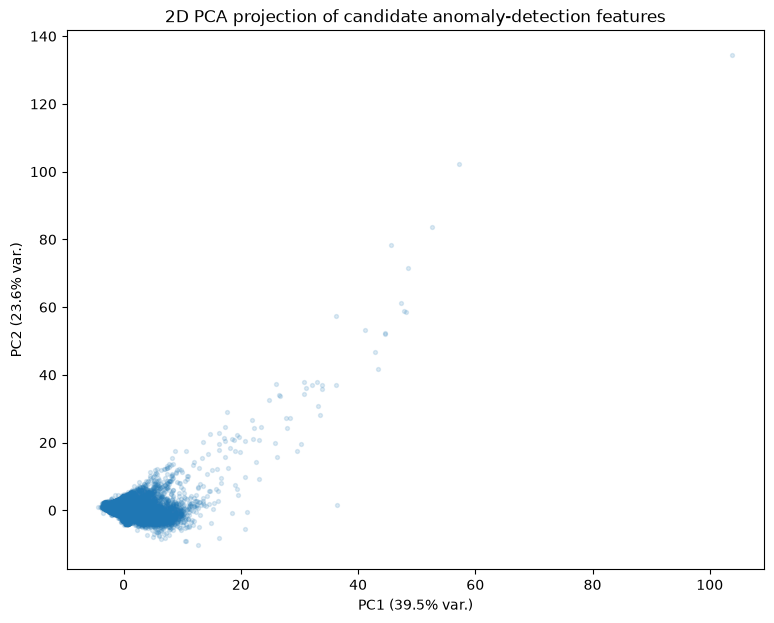

Explained variance ratio: [0.3949797  0.23593371]


In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = [
    "log_price", "log_sqm", "num_rooms", "num_bathrooms",
    "price_per_sqm", "sqm_per_room", "baths_per_room",
    "price_relative_to_type", "price_relative_to_province"
]

pca_df = df_clean[pca_features].dropna()
X_scaled = StandardScaler().fit_transform(pca_df)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
plt.scatter(components[:, 0], components[:, 1], alpha=0.15, s=8)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.title("2D PCA projection of candidate anomaly-detection features")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

Some outliers are already shown in the graph, these may be some of the candidats that we are going to obtain later while using our trained models. The first two principal components capture 57.0% of the variance in the selected features. Most properties form a compact cluster, while a small number of observations are located far from the center of the distribution. These isolated points may represent the outliers. The PCA projection suggests that anomaly-detection methods are likely to identify a limited set of properties with markedly different characteristics from the rest of the dataset.

## 11. Risks and Limitations of the Dataset

These are some of the risks and limitations that are present in the dataset:

- **Information leakage**: `price_without_discount`, `discount_amount` and `price` are algebraically related. Using more than one of them as independent model features may risk the perfomance of the models. Only `price` (or`log_price`) and `discount_pct` should enter the final matrix (Section 12).
- **Redundant / highly correlated variables**: `price_per_sqm`, `price_per_room` and `price_per_bath` are all transformations of the same underlying `price` signal. Including all of them rises the influence of price-related information relative to spatial/layout information in the methods that we are using like LOF.
- **Geographic bias**: geographic statistics (such as means, z-scores) may be unstable for provinces with very few listings. Extreme `price_zscore_by_province` values may appear reflecting sample size and not anomalies. We should consider a minimum-count threshold before showing province-level outliers.
- **Single-platform bias**: all data comes from one scraping source: Booking. Features such as pricing behavior, listing structure, and property mix on this platform may not generalize to other websites.
- **Temporal bias**: the data represents a single date (`current_date`). Seasonal pricing effects (summer fees) may affect the results which will be variant depending on the scraped date when the data was obtained.
- **Real atypical records vs. data errors**: not every extreme value is a data-entry error (a 500 sqm villa is plausible, while a listing with 1 sqm is almost certainly not). We produced section 9's business rules to show these records rather than silently dropping them.

In [70]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Solo variables numéricas continuas candidatas (sin dummies, sin identificadores)
vif_cols = ['log_price', 'log_sqm', 'num_rooms', 'num_bathrooms',
            'price_per_sqm', 'price_per_room', 'price_per_bath',
            'sqm_per_room', 'rooms_per_sqm', 'baths_per_room',
            'discount_pct', 'price_relative_to_province']

X_vif = df_clean[vif_cols].dropna()

vif_data = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

vif_data

,variable,VIF
1,log_sqm,241.538078
0,log_price,179.198004
2,num_rooms,24.074393
3,num_bathrooms,20.463542
6,price_per_bath,13.793041
5,price_per_room,11.283350
9,baths_per_room,8.831207
7,sqm_per_room,7.845027
11,price_relative_to_province,7.359476
8,rooms_per_sqm,3.780749


**Multicollinearity check (VIF)**

With VIF we can confirm multicollinearity among price/size features. `log_sqm` (183), `log_price` (150), `num_rooms` (31), `baths_per_room` (26) and `num_bathrooms` (24) show extreme VIF, expected given that several engineered ratios (`price_per_bath`, `price_per_room`, `sqm_per_room`, `baths_per_room`) are algebraic functions of these base variables. `price_per_bath` (13.2) and `price_per_room` (10.7) also exceed the VIF > 10 threshold on their own.

We retain the base transformed variables (`log_price`, `log_sqm`, `num_rooms`, `num_bathrooms`) and the lowest derived ratio (`price_per_sqm`, VIF 2.1), while dropping `price_per_room` and `price_per_bath` from the final model matrix (Section 12.1) to reduce redundancy without losing discriminative signal.

## 12. Final Dataset Preparation for Isolation Forest / LOF

In this section we build the model-ready dataframe: selected variables, dropped variables, transformations, encoding and scaling.

### 12.1 Variable selection

**Dropped (identifiers / no discriminative value / leakage risk):** `location_id`, `room_name`, `municipality`, `locality`, `price_without_discount`, `discount_amount` (superseded by `discount_pct`), `stars` (superseded by `has_stars`), the raw business-rule flag columns from Section 9 (kept for validation, excluded from model input to avoid leakage), `price_per_room`, `price_per_bath` (multicollinearity confirmed by VIF, redundant with `log_price`, `log_sqm`, `num_rooms`, `num_bathrooms`)

**Kept: identifiers (only for traceability, not to train the models):** `id`, `room_id`, `name`,

**Kept: numeric model features:** `log_price`, `log_sqm`, `num_rooms`, `num_bathrooms`, `price_per_sqm`, `sqm_per_room`, `rooms_per_sqm`, `baths_per_room`, `discount_pct`, `price_relative_to_type`, `price_relative_to_province`, `has_stars`, `pool_flag`, `beach_flag`, `breakfast`, `cancellation`.

**Kept: categorical model features (to encode):**
`property_type`, `region`. `province` is excluded from direct encoding due to high cardinality (its effect is
already captured indirectly via `price_relative_to_province`).

### 12.2 Scaling choice: RobustScaler vs. StandardScaler

**We are selecting RobustScaler over StandardScaler:**
On one hand, StandardScaler centers on the mean and scales by standard deviation, both of which are themselves distorted by the heavy-tailed variables identified throughout this notebook (like `price`, `price_per_sqm`, etc). Moreover, a few extreme values would dominate the scaling factor and compress the bulk of "normal" observations into a narrow range, which is the opposite of what LOF requires to work well. On the other hand, RobustScaler uses the median and IQR, which are insensitive to the very outliers we ultimately want the models to detect, so the scaling doesn't get distorted.

In [71]:
from sklearn.preprocessing import RobustScaler

numeric_model_features = [
    "log_price", "log_sqm", "num_rooms", "num_bathrooms",
    "price_per_sqm", "sqm_per_room", "rooms_per_sqm", "baths_per_room", "discount_pct",
    "price_relative_to_type", "price_relative_to_province", "has_stars",
    "pool_flag", "beach_flag", "breakfast", "cancellation"
]

categorical_model_features = ["property_type", "region"]

id_columns = ["id", "room_id", "name"]  # kept only for traceability, not modeling

model_input_cols = numeric_model_features + categorical_model_features
df_model = df_clean[id_columns + model_input_cols].copy()

print("Rows before dropping remaining NaNs in model features:", len(df_model))
df_model = df_model.dropna(subset=numeric_model_features)
print("Rows after dropping NaNs:", len(df_model))

Rows before dropping remaining NaNs in model features: 108123
Rows after dropping NaNs: 108123


In [ ]:
# One-hot encode low-cardinality categoricals
df_encoded = pd.get_dummies(
    df_model,
    columns=categorical_model_features,
    prefix=categorical_model_features,
    drop_first=False
)

scaler = RobustScaler()
X_numeric_scaled = scaler.fit_transform(df_encoded[numeric_model_features])

df_numeric = pd.DataFrame(
    X_numeric_scaled,
    columns=numeric_model_features,
    index=df_encoded.index
)

df_dummies = df_encoded.drop(columns=id_columns + numeric_model_features)

df_final = pd.concat([df_encoded[id_columns], df_numeric, df_dummies], axis=1)

print(df_final.shape)
display(df_final.head())

(108123, 57)


,id,room_id,name,log_price,log_sqm,num_rooms,num_bathrooms,price_per_sqm,sqm_per_room,rooms_per_sqm,baths_per_room,discount_pct,price_relative_to_type,price_relative_to_province,has_stars,pool_flag,beach_flag,breakfast,cancellation,property_type_Agroturismo,property_type_Albergue,property_type_Apartahotel,property_type_Apartamento,property_type_Barco,property_type_Bed and breakfast,property_type_Camping,property_type_Camping resort,property_type_Casa o chalet,property_type_Casa rural,property_type_Chalet de montaña,property_type_Habitación en casa particular,property_type_Hostal o pensión,property_type_Hotel,property_type_Lodge,property_type_Love hotel,property_type_Posada u hostería,property_type_Resort,property_type_Villa,region_Andalucía,region_Aragón,region_Canary Islands,region_Cantabria,region_Castilla y León,region_Castilla-La Mancha,region_Cataluña,region_Ceuta,region_Comunidad Foral de Navarra,region_Comunidad Valenciana,region_Comunidad de Madrid,region_Extremadura,region_Galicia,region_Islas Baleares,region_La Rioja,region_Melilla,region_País Vasco,region_Principado de Asturias,region_Región de Murcia
0,10000125,1000012502,Apartamentos Villa Zoila Nigrán,0.205261,-0.265430,-0.5,0.0,0.615427,0.833333,-0.311005,0.666667,0.089112,0.362586,0.280080,0.0,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,10000734,1000073405,Hostal Carlos III,-1.117948,-0.515545,-1.0,-1.0,-0.454901,0.277778,-1.555024,-1.333333,0.000000,-0.357602,-0.891685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10001085,1000108501,Vive tu vida soñada delante del mar,0.159409,1.190594,0.0,0.0,-0.763108,2.638889,-0.773069,-0.333333,0.000000,0.302336,0.217663,0.0,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1000112,100011202,La Vista de Medina By La Vista Medina Stays,-0.569807,-1.240986,-0.5,0.0,1.091761,-0.833333,1.181818,0.666667,0.000000,-0.426138,-0.345525,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1000115,100011502,Hostal Catalina de Austria,-1.124398,-0.515545,-1.0,-1.0,-0.459233,0.277778,-1.555024,-1.333333,0.000000,-0.362785,-0.752920,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
# Persist the model-ready dataset
df_final.to_csv("dataset_anomaly_detection_ready.csv", index=False)
print("Saved: dataset_anomaly_detection_ready.csv")

Saved: dataset_anomaly_detection_ready.csv


### Final dataset summary

- **Variables selected**: 3 identifiers + 17 numeric (transformed/engineered) + 2 one-hot encoded categoricals (`property_type`, `region`).
- **Variables eliminated**: 2 identifiers, redundant price fields, raw `stars`, constant columns, high-cardinality `province`/`municipality`/`locality`.
- **Transformations**: `log1p` on `price`/`sqm`; ratio features for layout (`sqm_per_room`, `rooms_per_sqm`, `baths_per_room`); segment-relative price features to control for type/region effects.
- **Encoding**: one-hot for `property_type` and `region` (both low/medium cardinality).
- **Scaling**: `RobustScaler`, chosen specifically because it does not let the extreme values we want Isolation Forest / LOF to detect distort the scaling itself.
- **Output**: `df_final` / `dataset_anomaly_detection_ready.csv`, indexed with traceable `id`/`room_id`/`name` columns kept alongside (not fed to the models), so that any anomaly a model flags can be traced back to a real listing for characterization.

**We will use this dataset as the input for the next notebook: Isolation Forest and LOF
training.**